In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pandas import DataFrame as DF

import wandb
from models import HierarchicalModel
from utils import rate_code

mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")


/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/usr/local/lib/python3.8/dist-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(


In [2]:
config = {
    "gabor_filters_fname": "/src/project/computed/center_masked_surround_gabors.npy",
    "stimuli_fname": "/src/project/computed/center_cut_congruent_incongruent_all.npy",
    "global_orientation_lower_bound": 0,
    "global_orientation_upper_bound": 180,
    "rate_code_signature": "inv_(base+vonmises)",
    "baseline_firing_rate": 0.001,
    "vonmises_loc": 0,
    "vonmises_kappa": 25,
    "stimulus_std": 0.1,
    "prior_sampling_draws": 10,
    "posterior_sampling_tunes": 1000,
    "posterior_sampling_draws": 1000,
    "posterior_sampling_chains": 4,
    "posterior_sampling_cores": 4,
    "posterior_sampling_tries": 2,
    "random_seed": 42,
}

In [3]:
gabor_filters = np.load(config["gabor_filters_fname"])
orientation_preferences_fname = (
    config["gabor_filters_fname"][:-4] + "_orientations.npy"
)
orientation_preferences = np.load(orientation_preferences_fname)
n_neurons = gabor_filters.shape[0]
model = HierarchicalModel(
    n_neurons=n_neurons,
    global_orientation_bounds=(
        np.deg2rad(config["global_orientation_lower_bound"]),
        np.deg2rad(config["global_orientation_upper_bound"]),
    ),
    gabor_filters=gabor_filters,
    orientation_preferences=orientation_preferences,
    stimulus_std=config["stimulus_std"],
    rate_code_signature=config["rate_code_signature"],
    vonmises_loc=config["vonmises_loc"],
    vonmises_kappa=config["vonmises_kappa"],
    baseline_firing_rate=config["baseline_firing_rate"],
)

In [4]:
blank_stimulus, center_only_stimulus, incongruent_surround_stimulus, incongruent_no_center_stimulus, congruent_surround_stimulus, congruent_no_center_stimulus, contrast_matched_congruent_stimulus = np.load(
    config["stimuli_fname"]
)

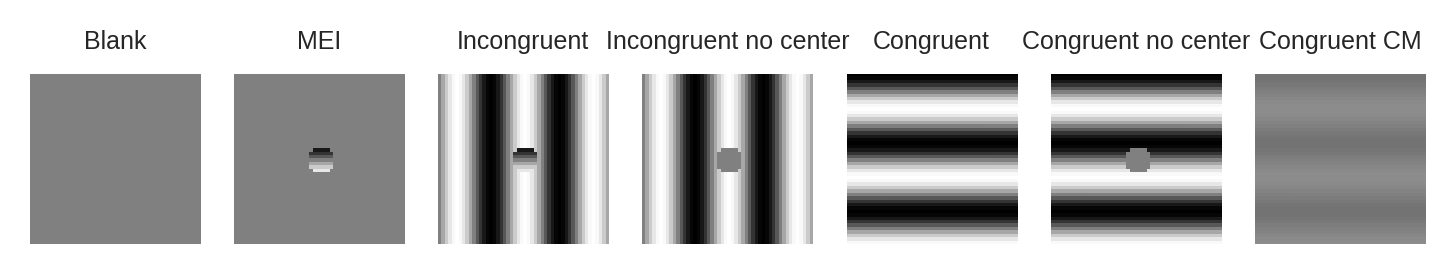

In [5]:
# imshow all stimuli
fig, axs = plt.subplots(1, 7, dpi=300)
axs[0].imshow(blank_stimulus, cmap="gray", vmin=-1, vmax=1)
axs[0].set_title("Blank", fontsize=6)
axs[0].axis("off")
axs[1].imshow(center_only_stimulus, cmap="gray", vmin=-1, vmax=1)
axs[1].set_title("MEI", fontsize=6)
axs[1].axis("off")
axs[2].imshow(incongruent_surround_stimulus, cmap="gray", vmin=-1, vmax=1)
axs[2].set_title("Incongruent", fontsize=6)
axs[2].axis("off")
axs[3].imshow(incongruent_no_center_stimulus, cmap="gray", vmin=-1, vmax=1)
axs[3].set_title("Incongruent no center", fontsize=6)
axs[3].axis("off")
axs[4].imshow(congruent_surround_stimulus, cmap="gray", vmin=-1, vmax=1)
axs[4].set_title("Congruent", fontsize=6)
axs[4].axis("off")
axs[5].imshow(congruent_no_center_stimulus, cmap="gray", vmin=-1, vmax=1)
axs[5].set_title("Congruent no center", fontsize=6)
axs[5].axis("off")
axs[6].imshow(contrast_matched_congruent_stimulus, cmap="gray", vmin=-1, vmax=1)
axs[6].set_title("Congruent CM", fontsize=6)
axs[6].axis("off")
plt.show()


In [6]:
blank_trace, center_cut_trace, incongruent_trace, incongruent_no_center_trace, congruent_trace, congruent_no_center_trace, contrast_matched_trace = [
    model.sample_posterior(
        observed_stimulus=stimulus,
        draws=config["posterior_sampling_draws"],
        tunes=config["posterior_sampling_tunes"],
        chains=config["posterior_sampling_chains"],
        cores=config["posterior_sampling_cores"],
        random_seed=config["random_seed"],
        return_inferencedata=False,
    )
    for stimulus in [blank_stimulus, center_only_stimulus, incongruent_surround_stimulus, incongruent_no_center_stimulus, congruent_surround_stimulus, congruent_no_center_stimulus, contrast_matched_congruent_stimulus]
]

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_orientation, neurons]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_orientation, neurons]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
There were 44 divergences after tuning. Increase `target_accept` or reparameterize.
There were 89 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5537, but should be close to 0.8. Try to increase the number of tuning steps.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_orientation, neurons]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
There were 15 divergences after tuning. Increase `target_accept` or reparameterize.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_orientation, neurons]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.
There were 53 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6878, but should be close to 0.8. Try to increase the number of tuning steps.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_orientation, neurons]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_orientation, neurons]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_orientation, neurons]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
There were 22 divergences after tuning. Increase `target_accept` or reparameterize.
There were 312 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.4706, but should be close to 0.8. Try to increase the number of tuning steps.
There were 250 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5123, but should be close to 0.8. Try to increase the number of tuning steps.
There were 106 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6455, but should be close to 0.8. Try to increase the number of tuning steps.


In [7]:
def analyze_posterior(trace, gabor_filters, config):
    fig_samples, axs_samples = plt.subplots(
        nrows=2, ncols=5, dpi=300, sharex="row", sharey="row"
    )
    fig_samples.suptitle("Posterior samples", fontsize=8)
    for idx, ax in enumerate(axs_samples[0]):
        response = trace["neurons"][:, idx]
        response_mean = np.mean(trace["neurons"][:, idx].ravel())
        sns.histplot(
            response.ravel(), color="green", stat="probability", element="step", ax=ax
        )
        ax.text(0.05, 0.95, idx + 1, fontsize=6, transform=ax.transAxes)
        ax.text(0.5, 0.95, f"{response_mean:.5f}", fontsize=6, transform=ax.transAxes)
        ax.tick_params(axis="both", which="major", labelsize=5)
        # reduce the font size of the x and y labels
        ax.xaxis.label.set_size(5)
        ax.yaxis.label.set_size(5)
        # set a title for the subplot (the neuron number)
        ax.set_title(f"Neuron {idx+1}", fontsize=6)
    for idx, ax in enumerate(axs_samples[1]):
        ax.imshow(gabor_filters[idx], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
    log_dict = {
        "Posterior Samples": wandb.Image(fig_samples),
    }

    corr = np.corrcoef(trace["neurons"].T)
    fig_corr, ax_corr = plt.subplots(dpi=300)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, cmap="seismic", ax=ax_corr)
    ax_corr.set_facecolor("white")
    ax_corr.set_aspect("equal")
    ax_corr.set_xticklabels(range(1, 6))
    ax_corr.set_yticklabels(range(1, 6))
    ax_corr.set_title("Posterior correlation matrix of neuron samples", fontsize=8)
    log_dict.update({"Posterior Correlation": wandb.Image(fig_corr)})

    fig_orientation, ax_orientation = plt.subplots(dpi=300)
    sns.histplot(
        trace["global_orientation"].ravel(),
        color="orange",
        stat="probability",
        element="step",
        ax=ax_orientation,
    )
    ax_orientation.set_title("Posterior samples of orientation", fontsize=8)
    ax_orientation.set_xlabel("Orientation ($\degree$)", fontsize=6)
    ax_orientation.set_ylabel("Probability", fontsize=6)
    ax_orientation.tick_params(axis="both", which="major", labelsize=5)
    # convert xtick labels to degrees
    xticks = ax_orientation.get_xticks()
    xticklabels = [f"{int(np.rad2deg(xtick))}" for xtick in xticks]
    ax_orientation.set_xticklabels(xticklabels)
    ax_orientation.xaxis.label.set_size(5)
    ax_orientation.yaxis.label.set_size(5)

/tmp/ipykernel_8623/2017332329.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_orientation.set_xticklabels(xticklabels)
/tmp/ipykernel_8623/2017332329.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_orientation.set_xticklabels(xticklabels)
/tmp/ipykernel_8623/2017332329.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_orientation.set_xticklabels(xticklabels)
/tmp/ipykernel_8623/2017332329.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_orientation.set_xticklabels(xticklabels)
/tmp/ipykernel_8623/2017332329.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_orientation.set_xticklabels(xticklabels)
/tmp/ipykernel_8623/2017332329.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_orientation.set_xticklabels(xticklabels)
/tmp/ipykernel_8623/2017332329.py:38: RuntimeW

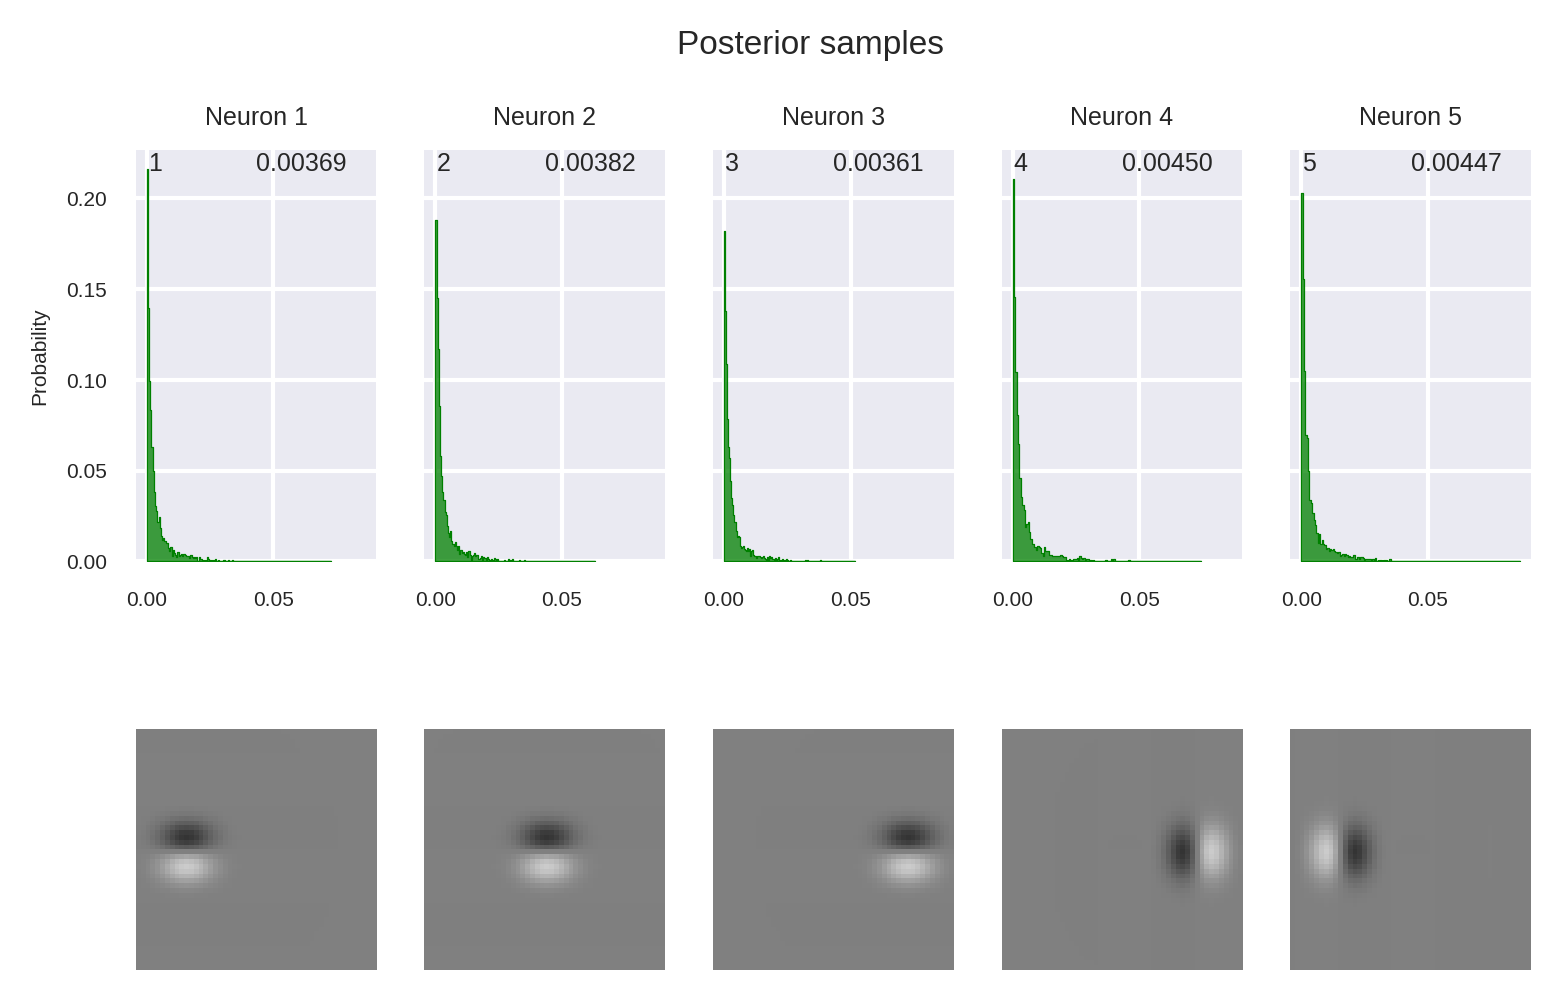

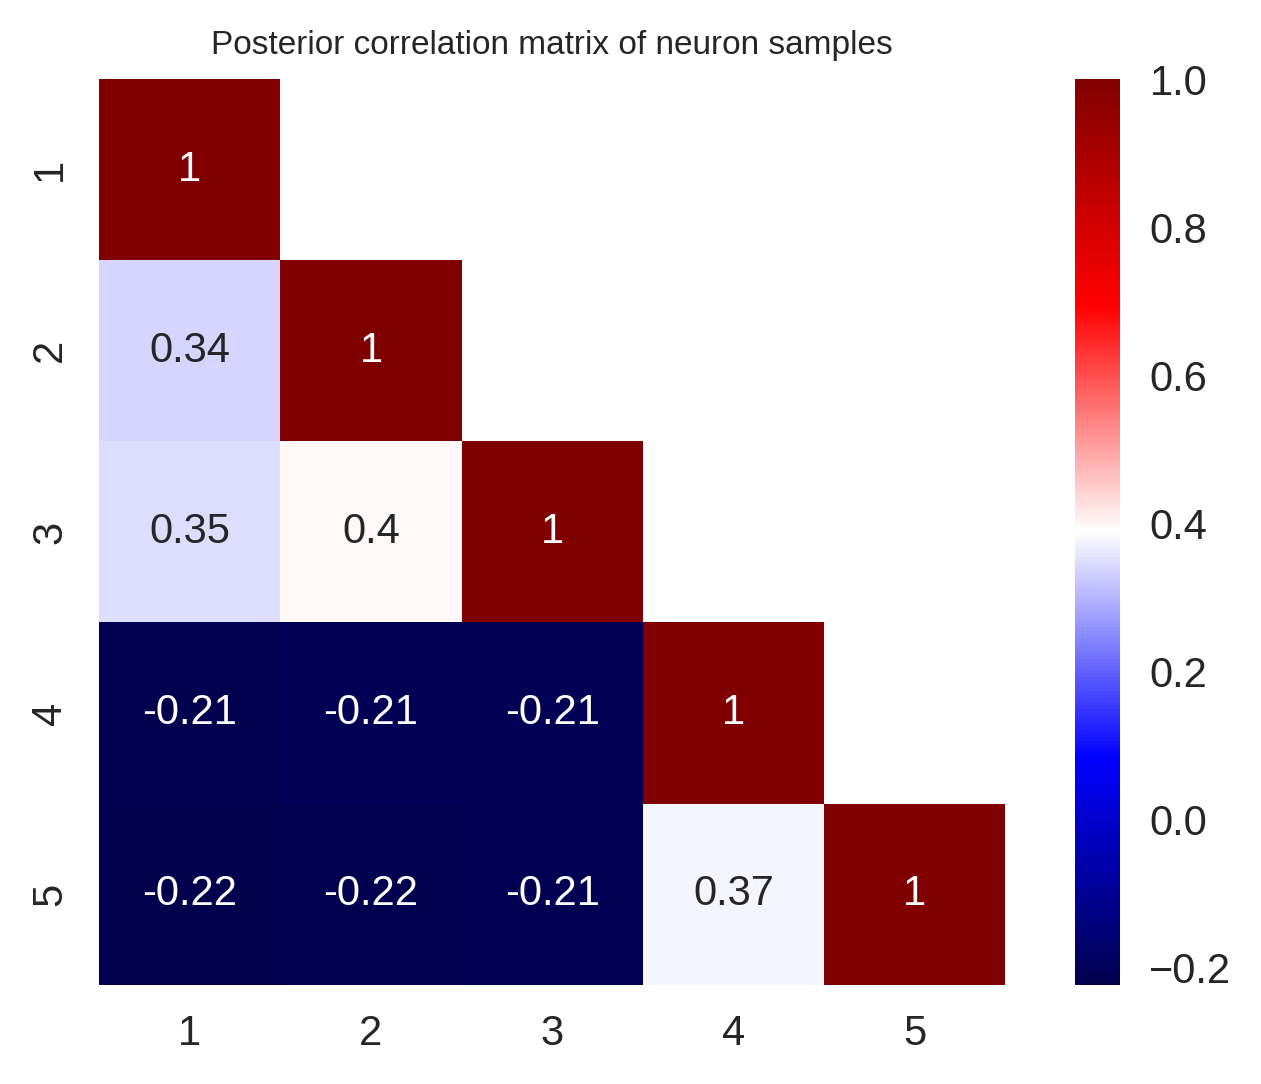

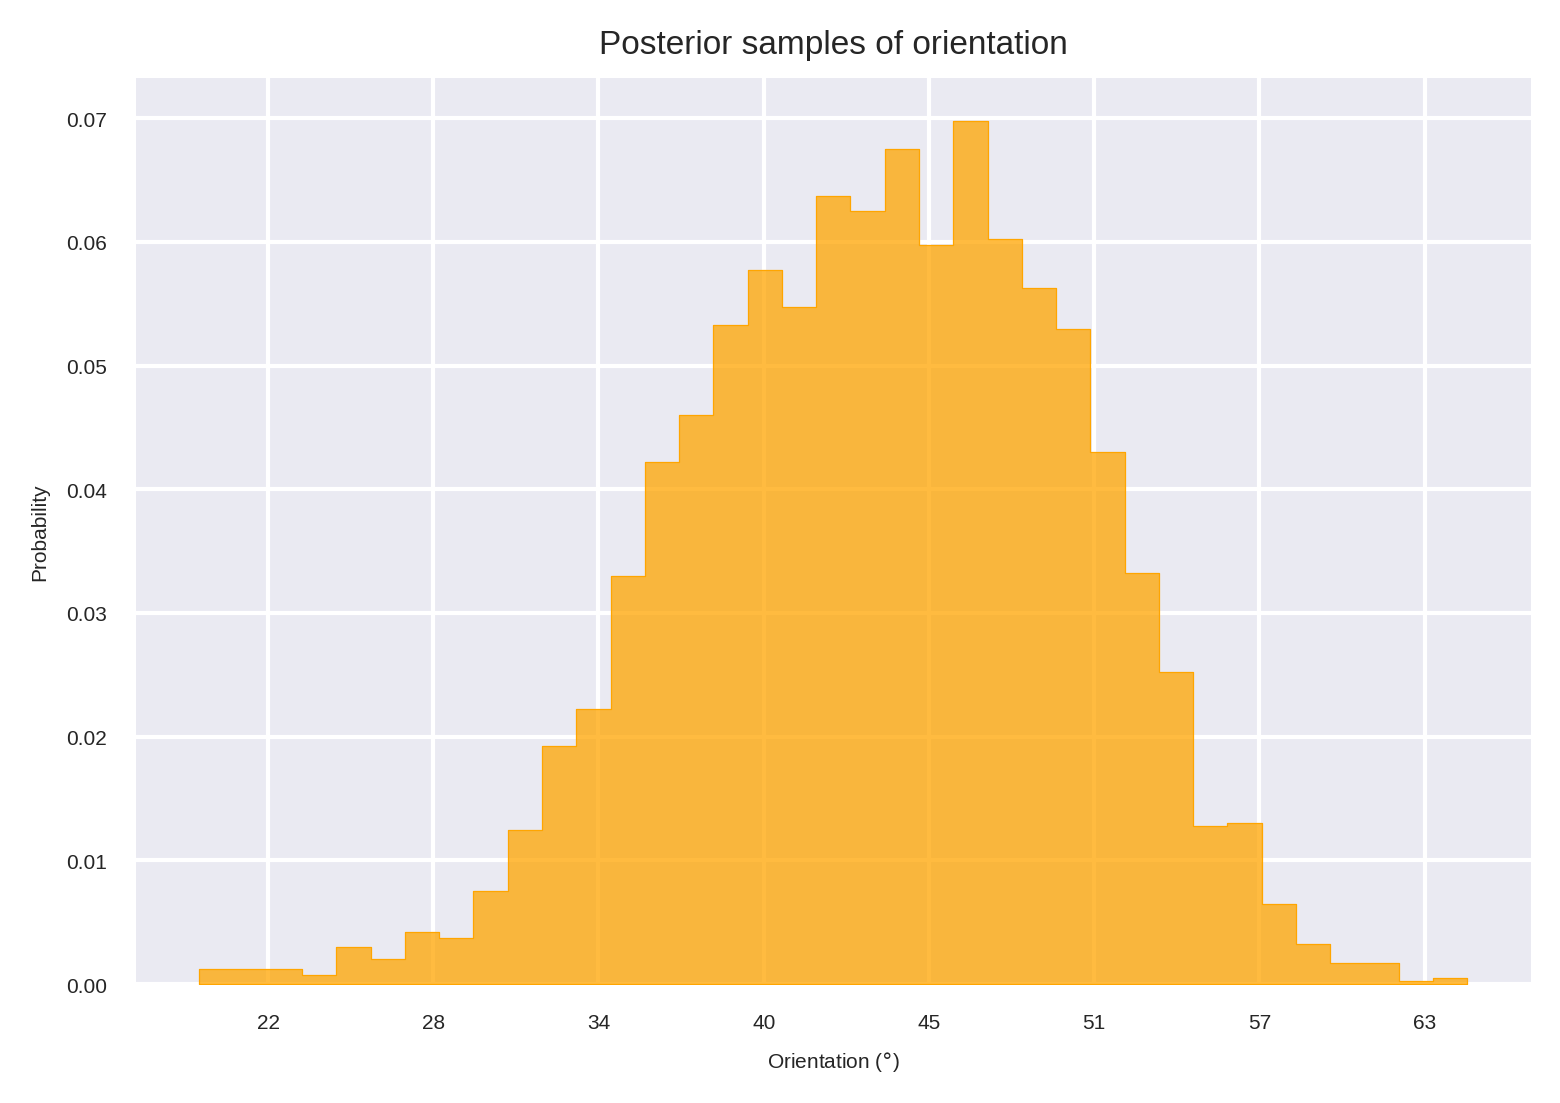

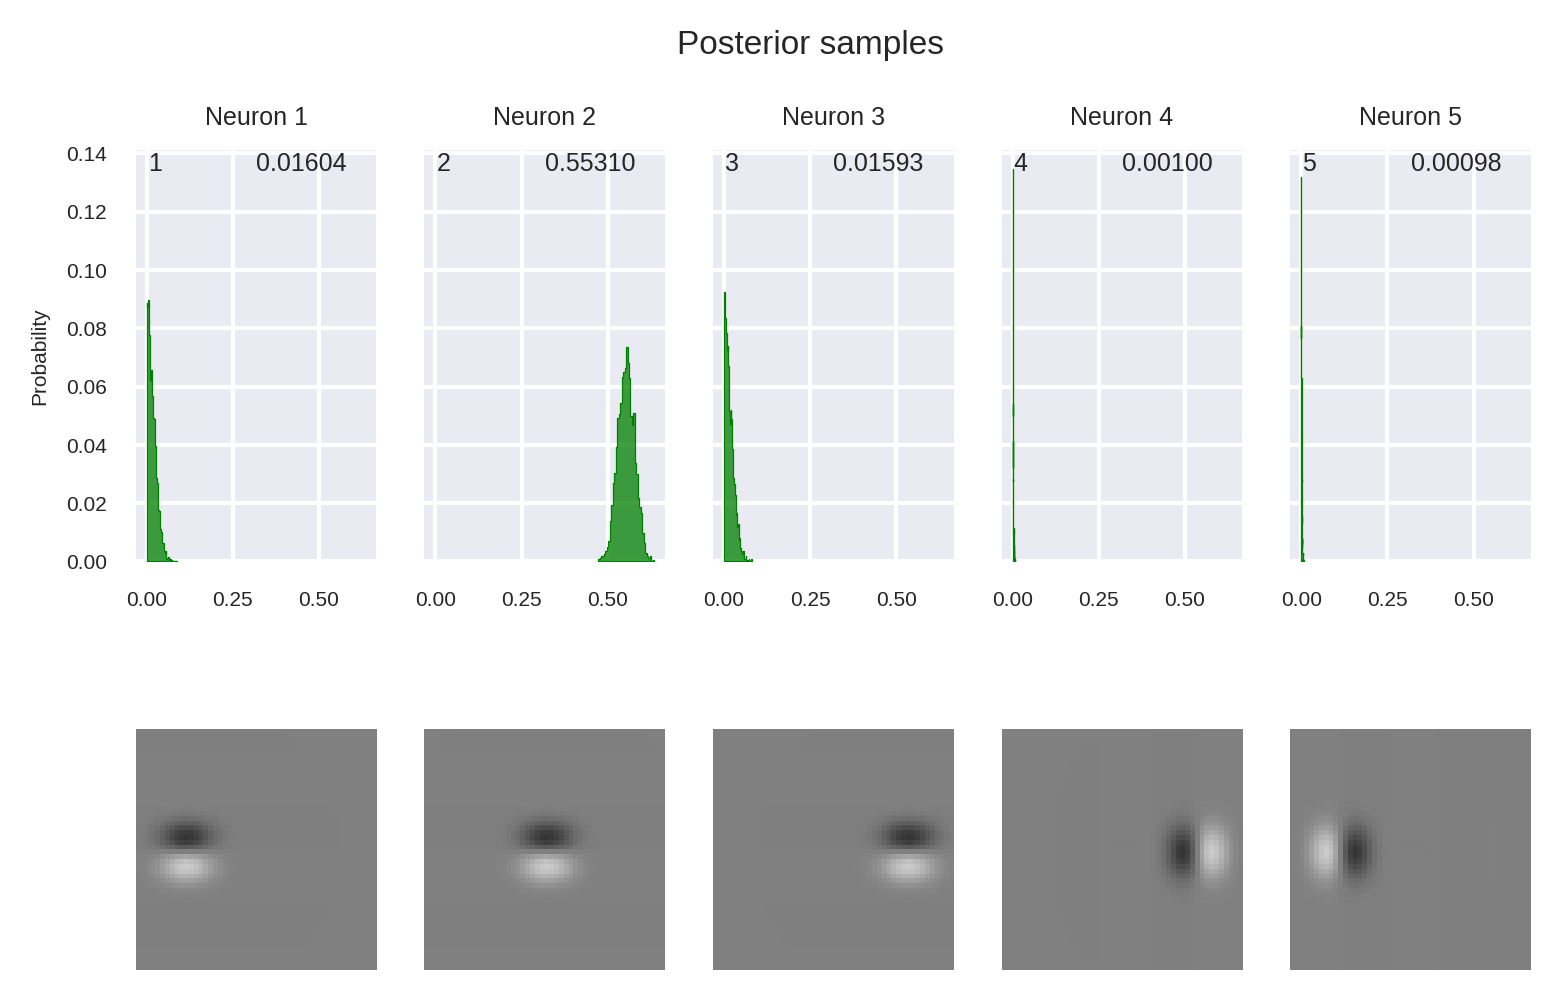

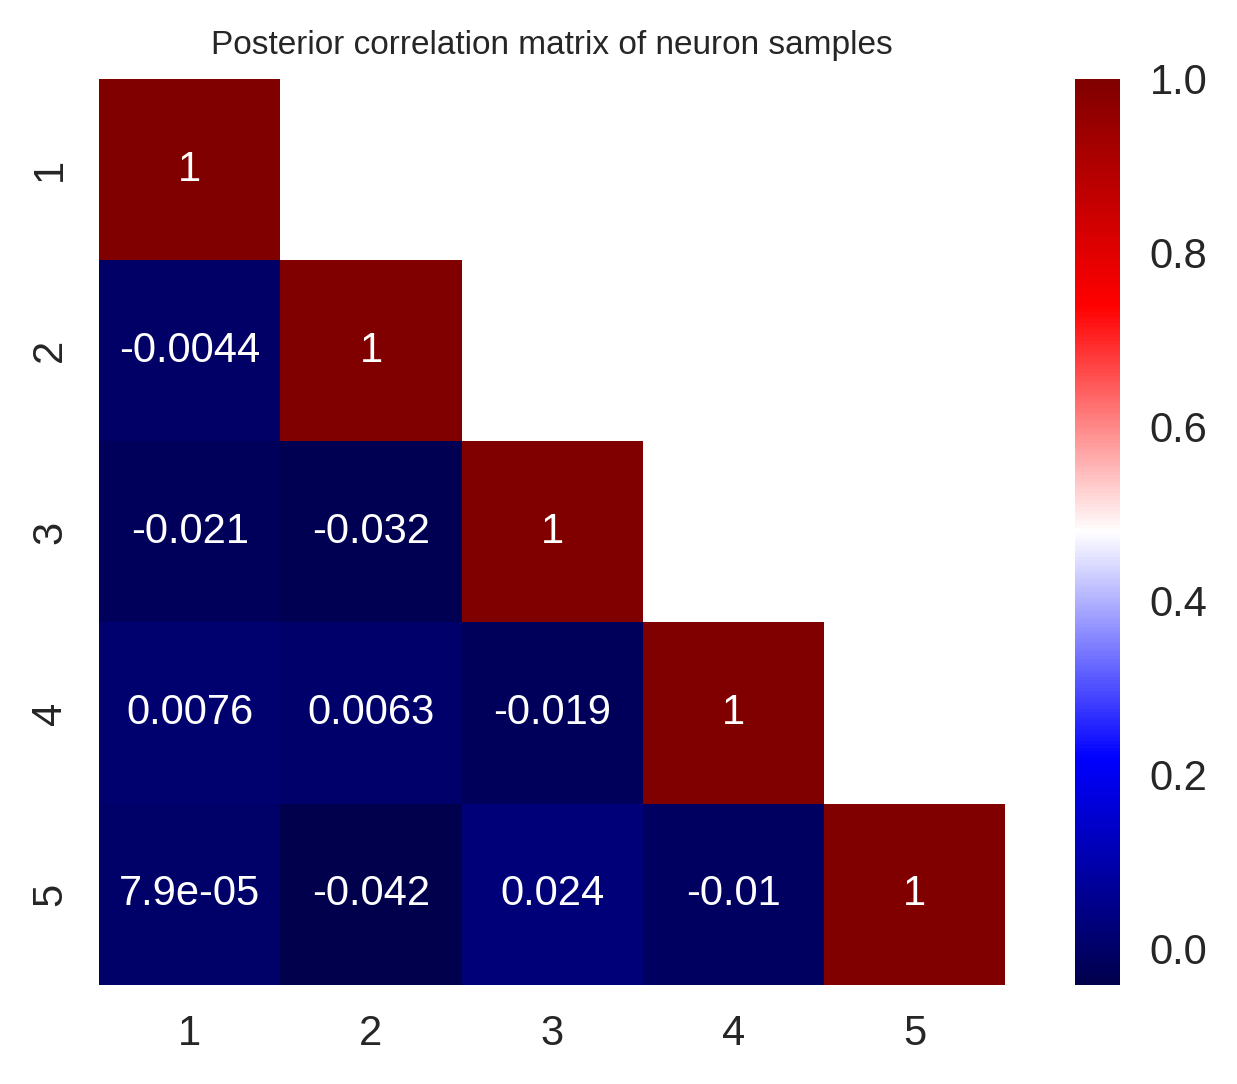

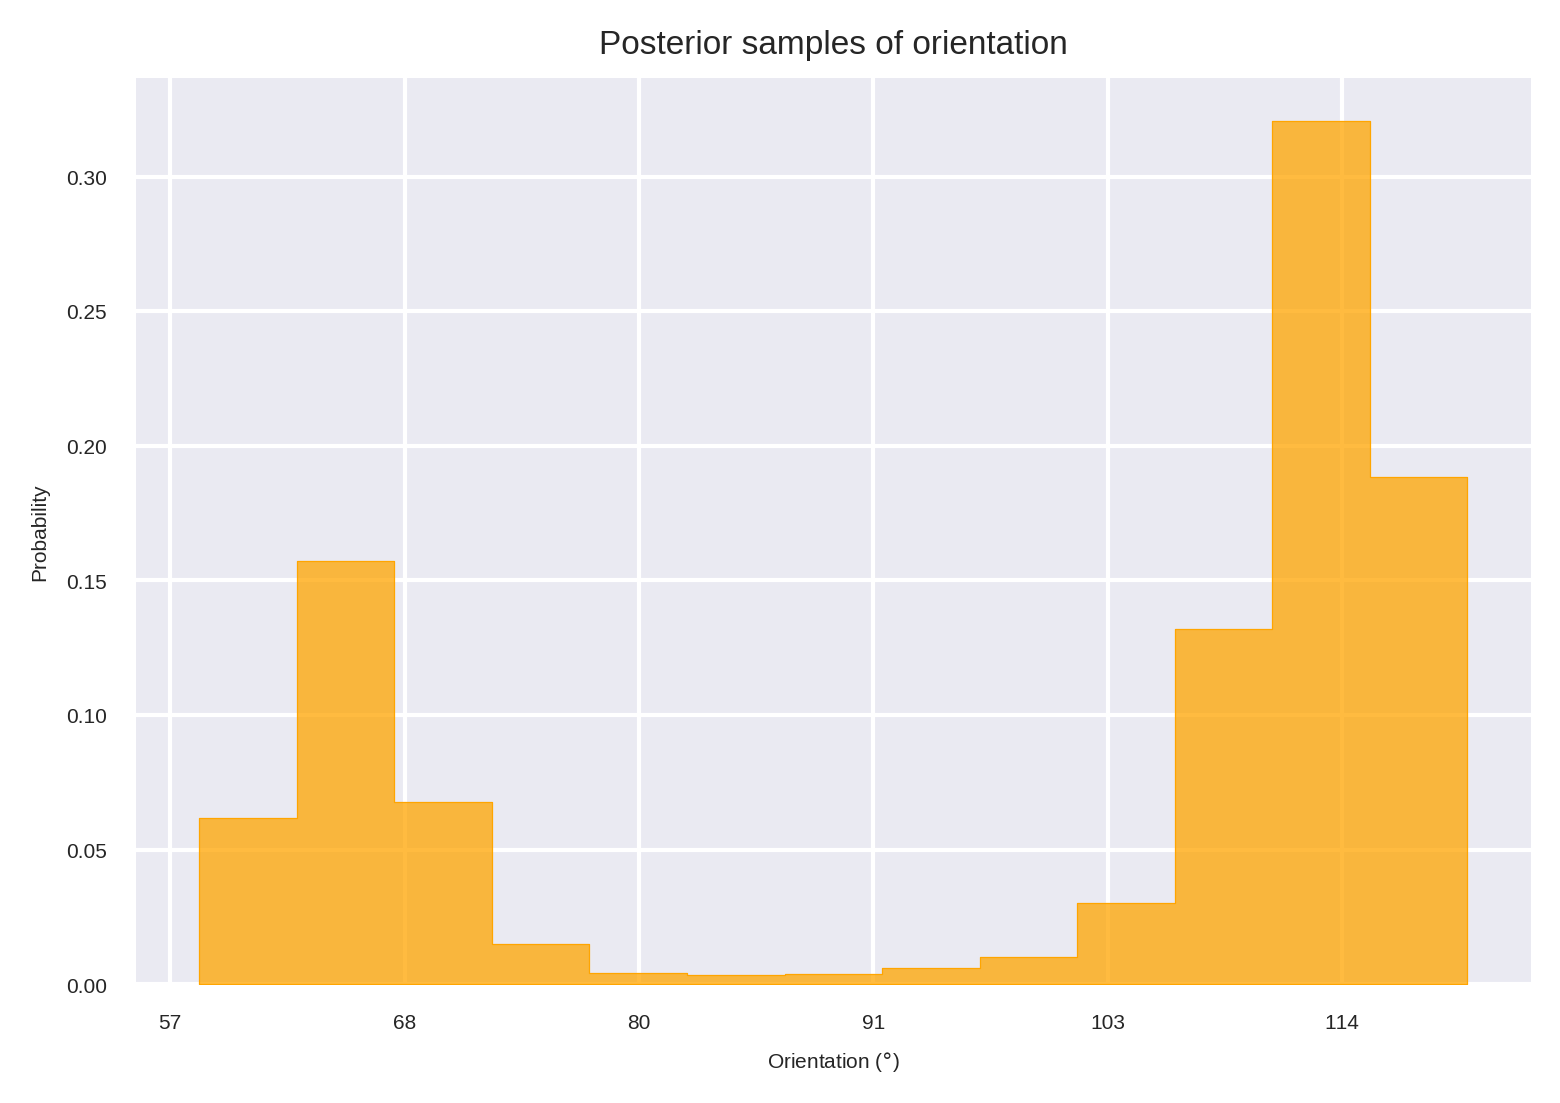

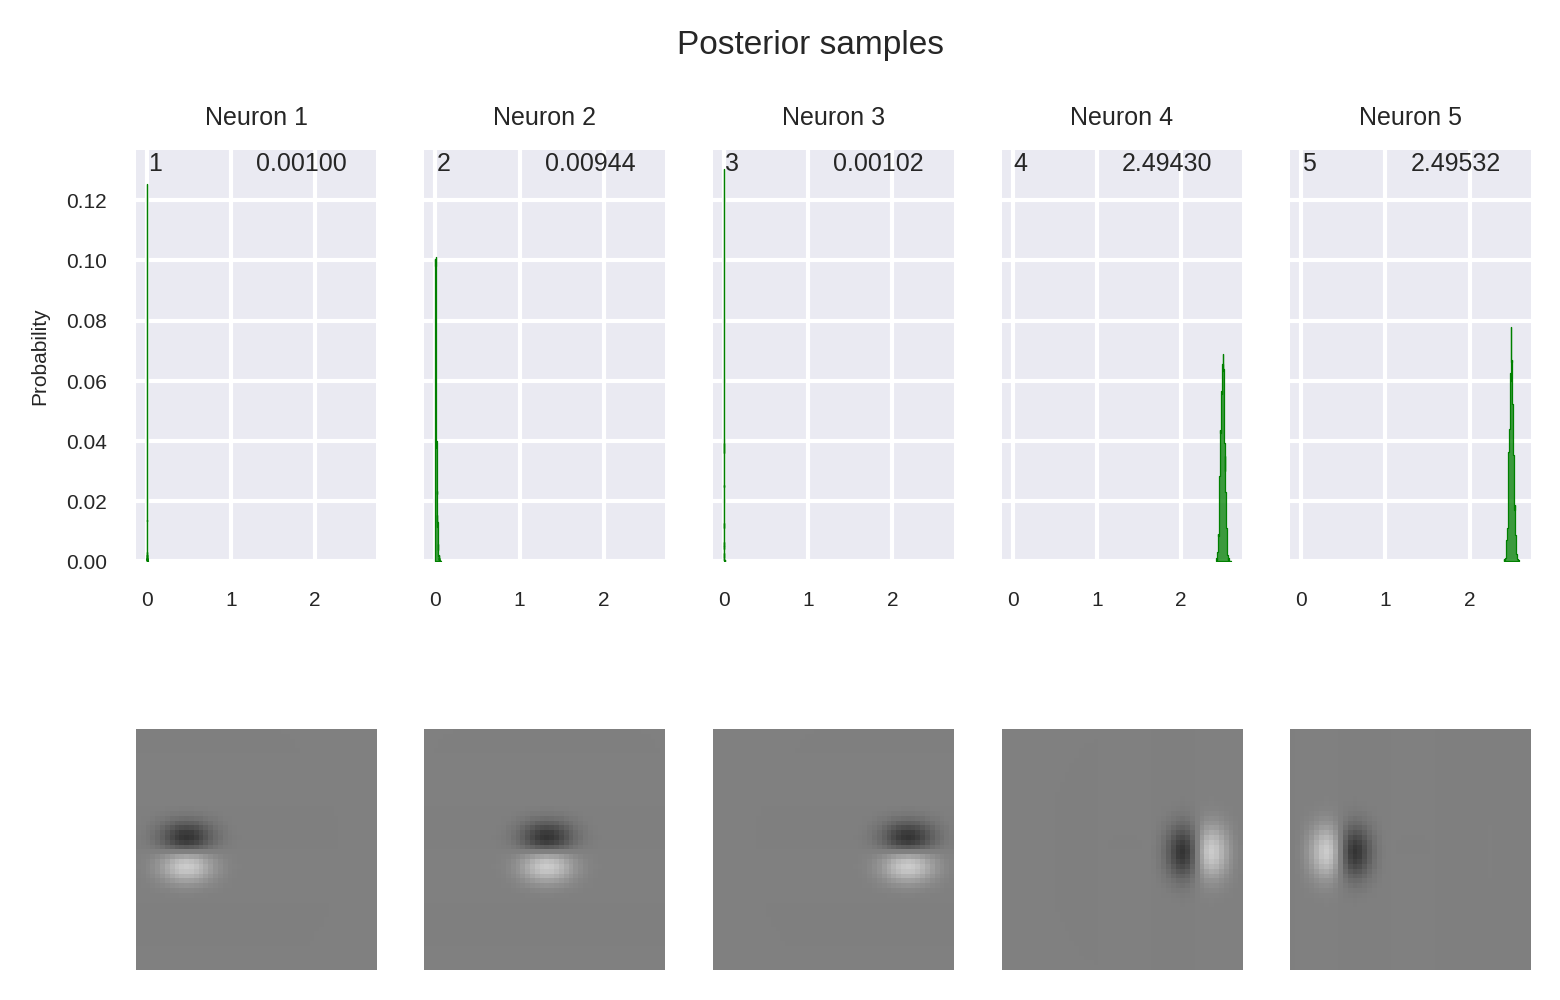

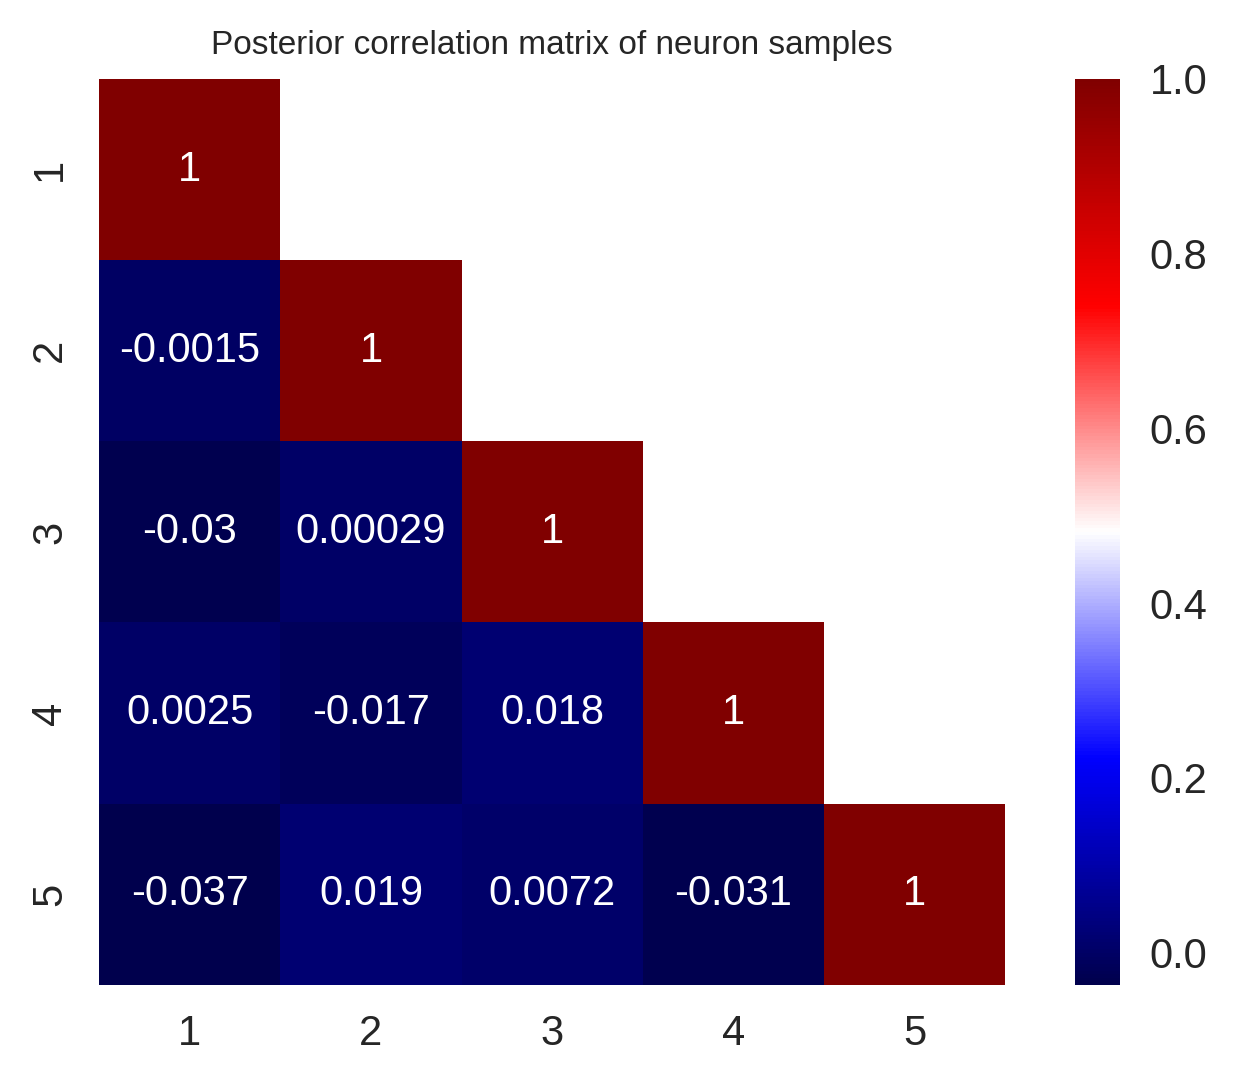

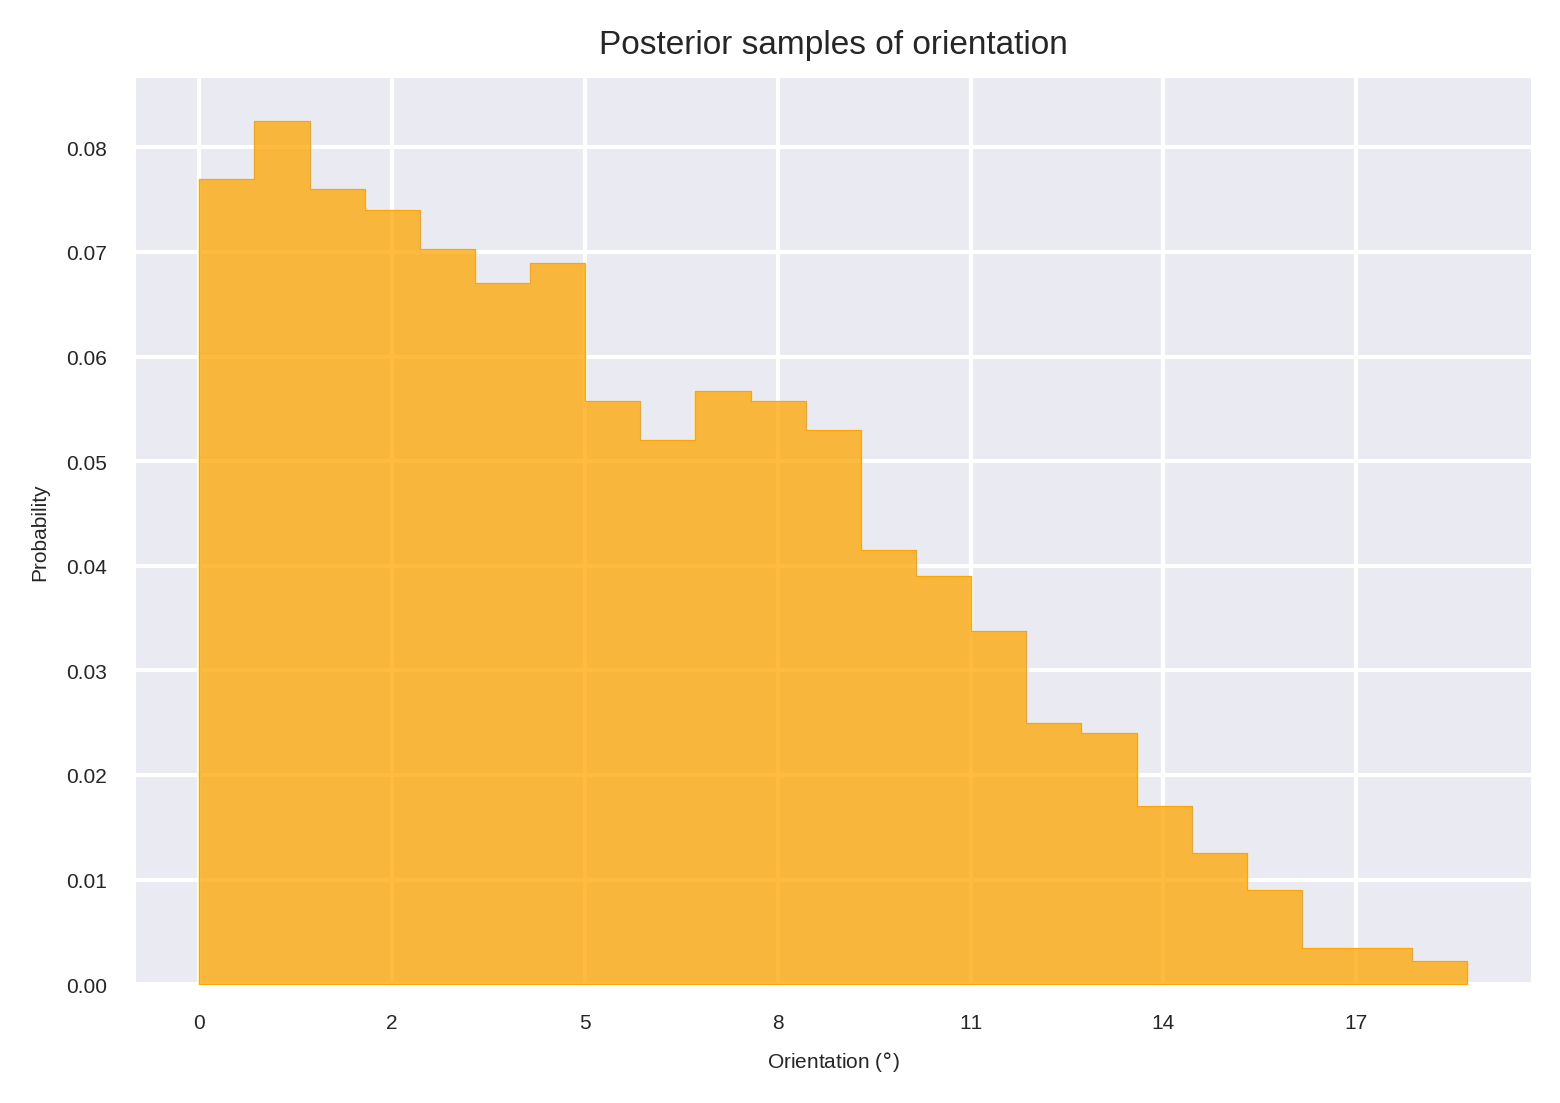

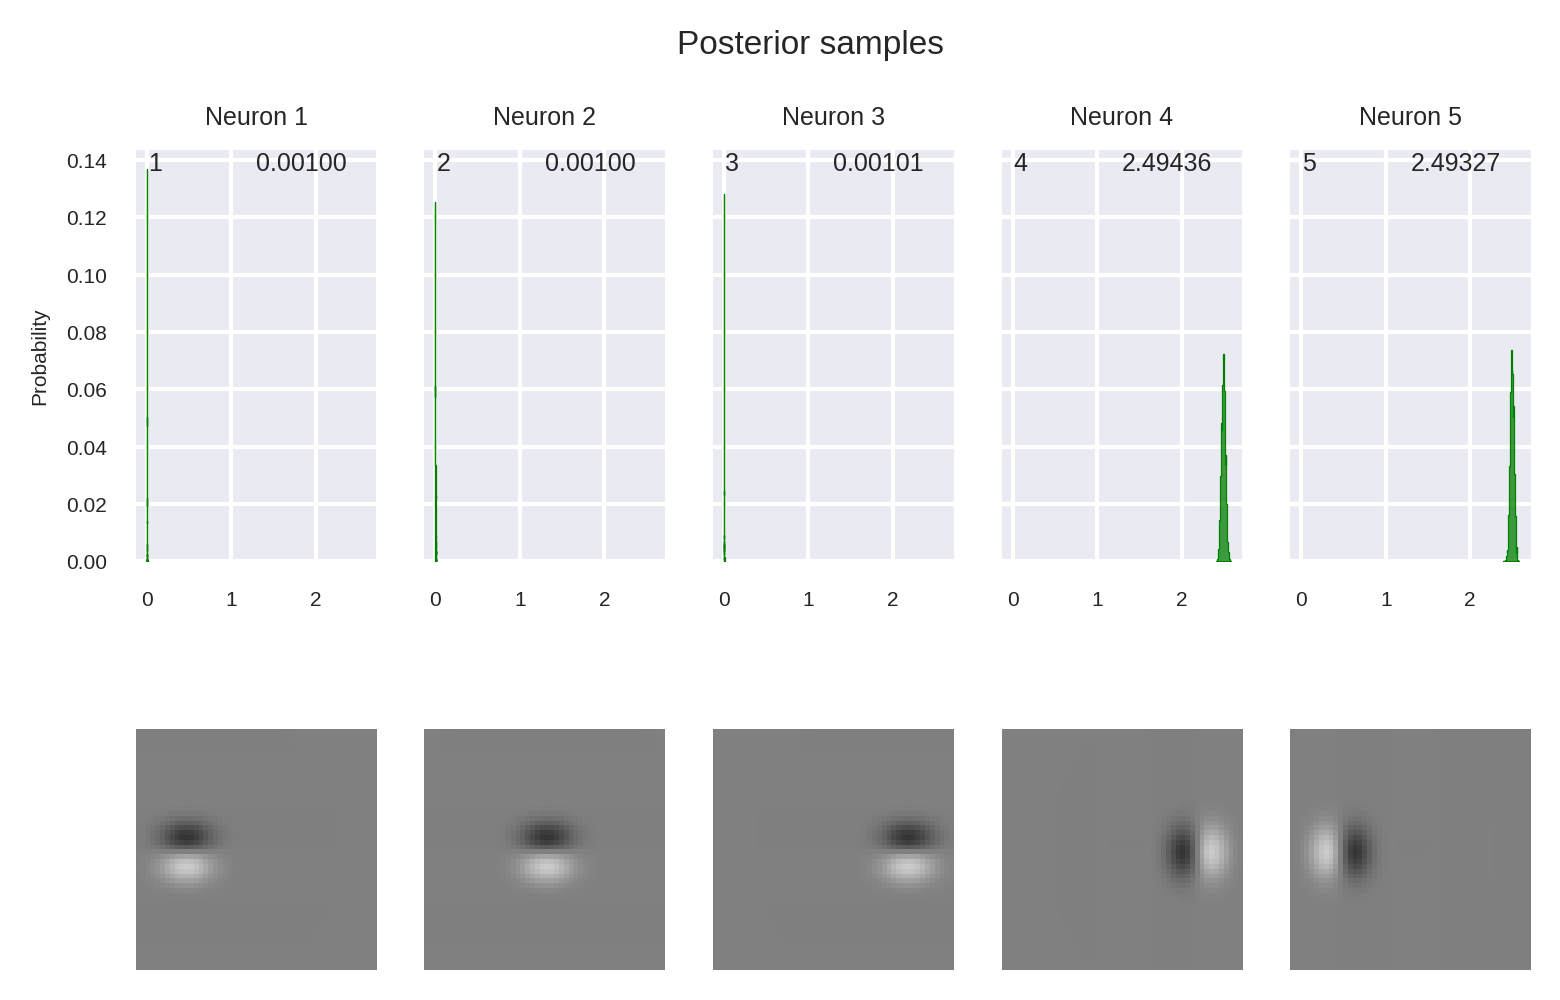

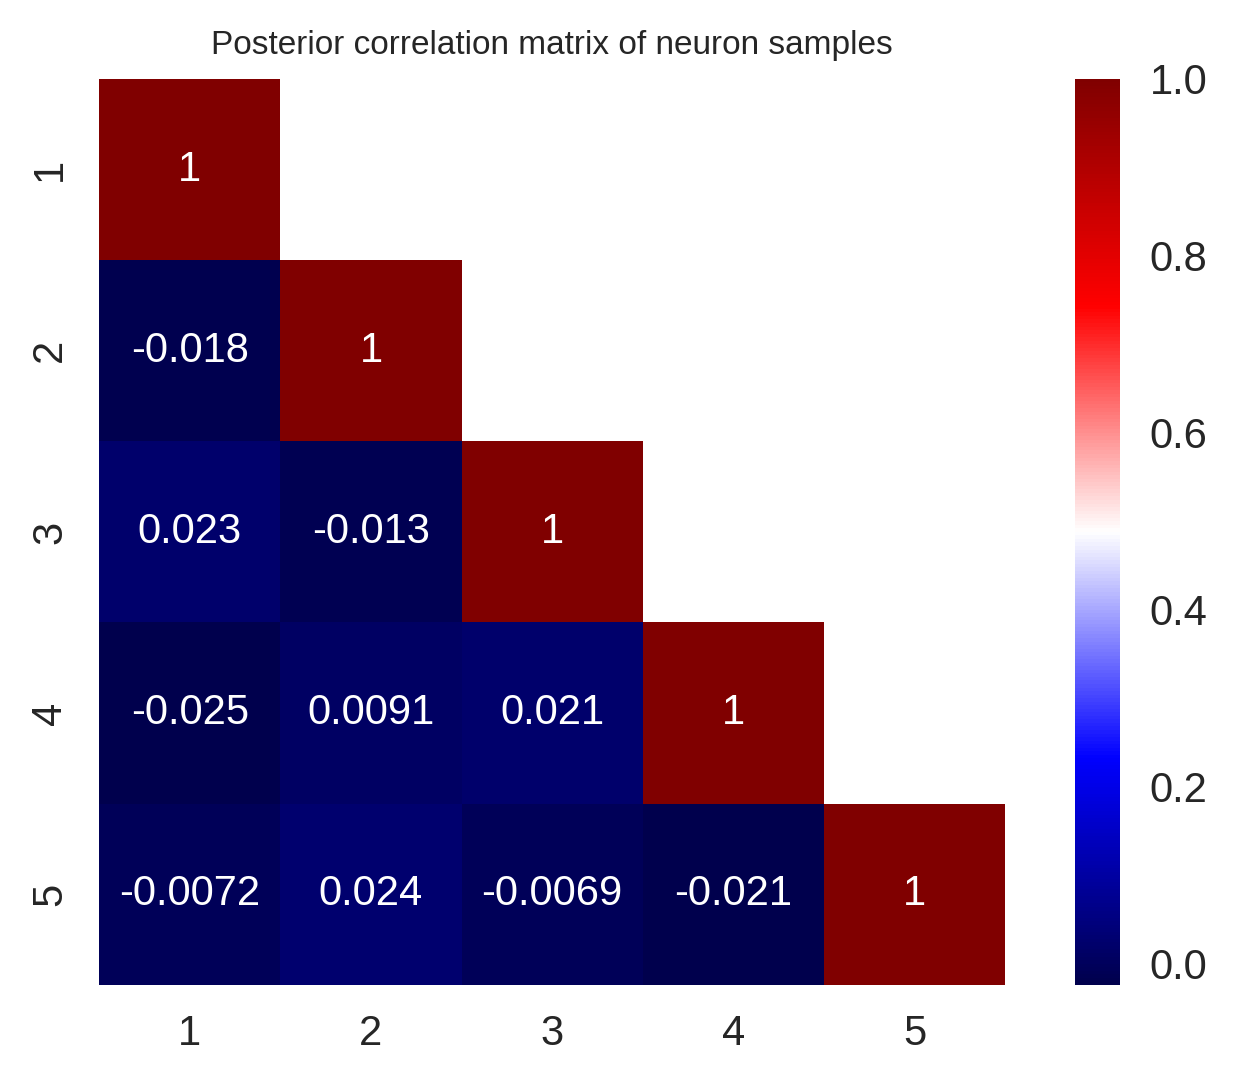

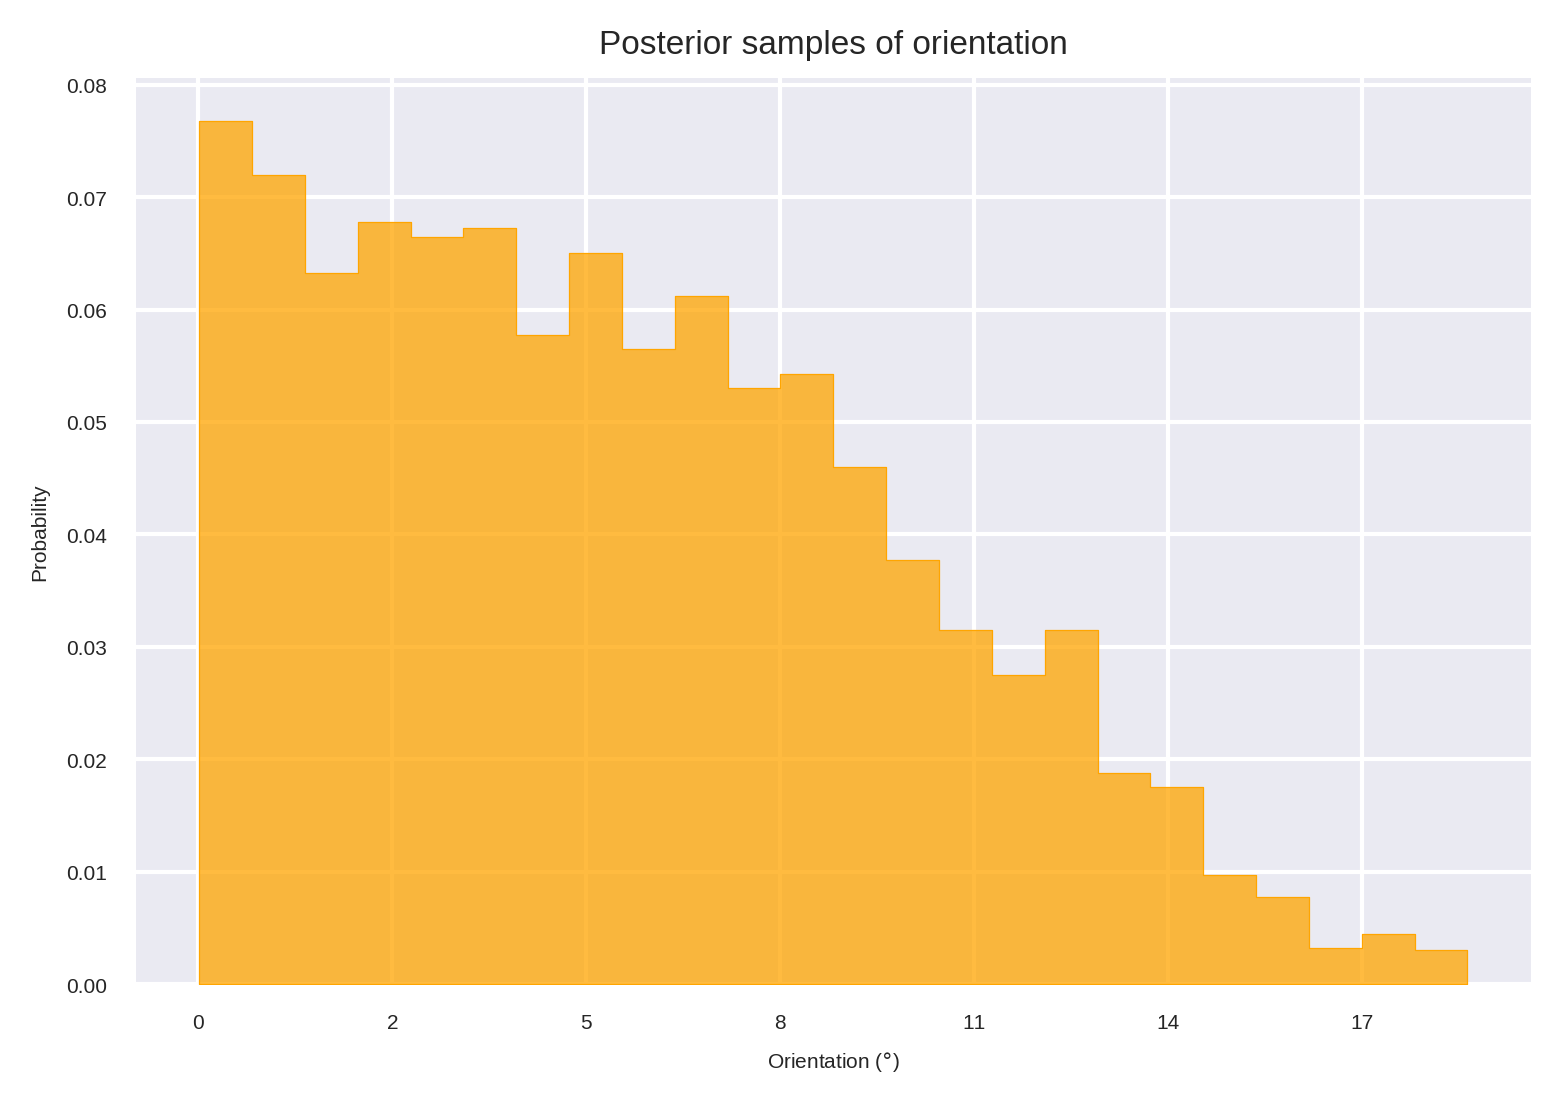

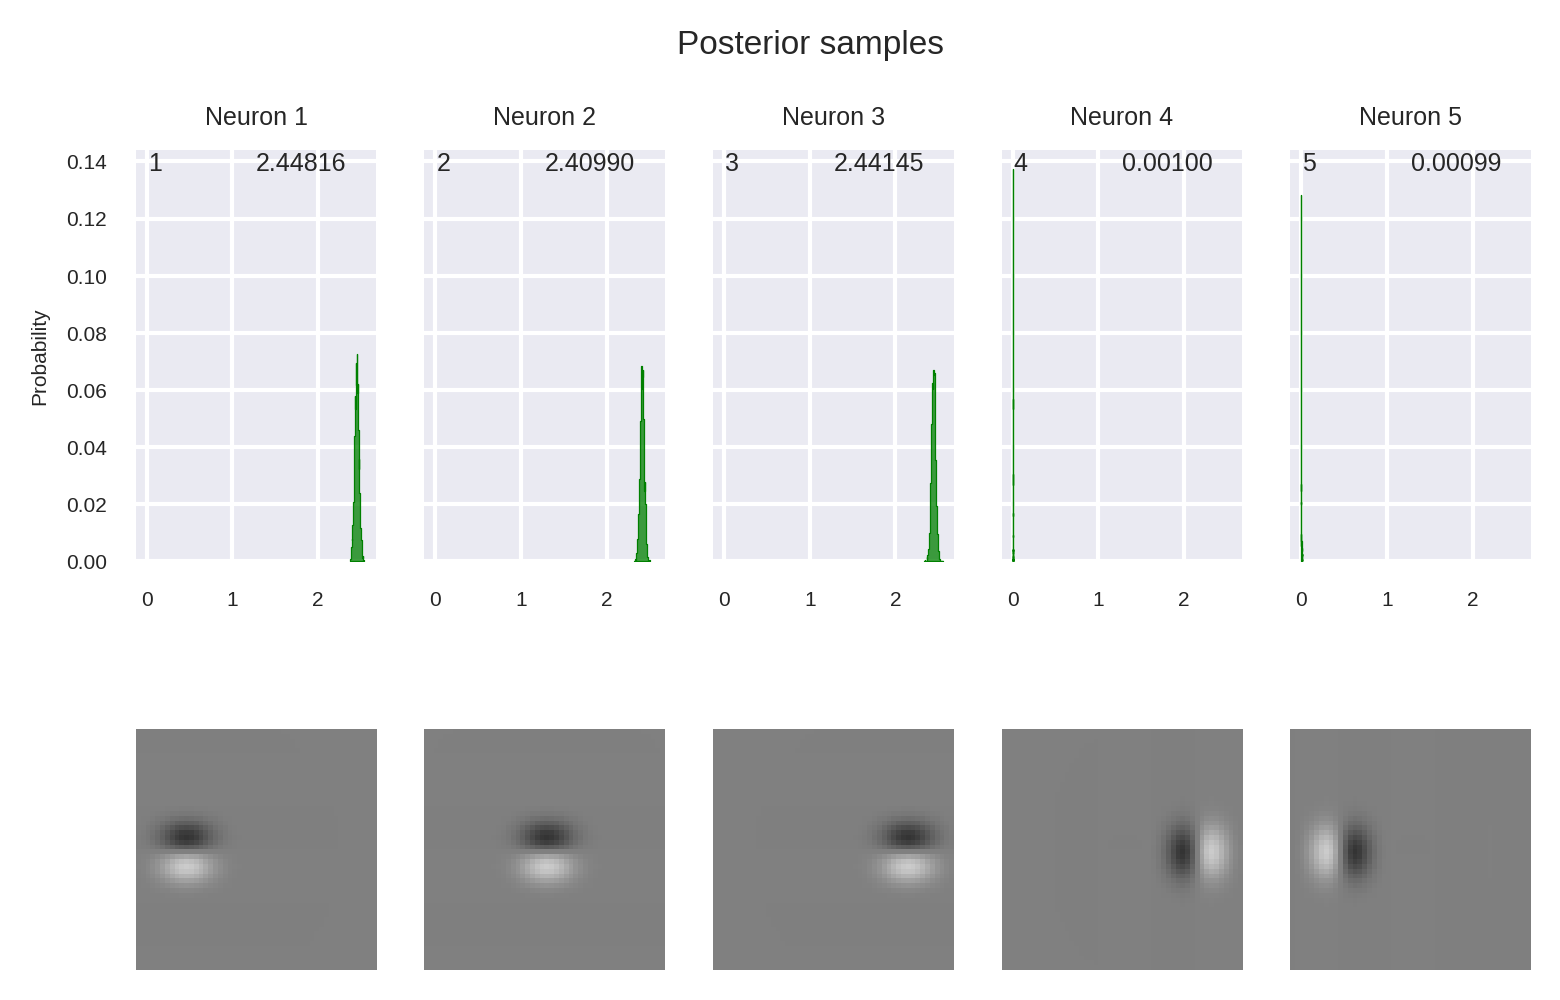

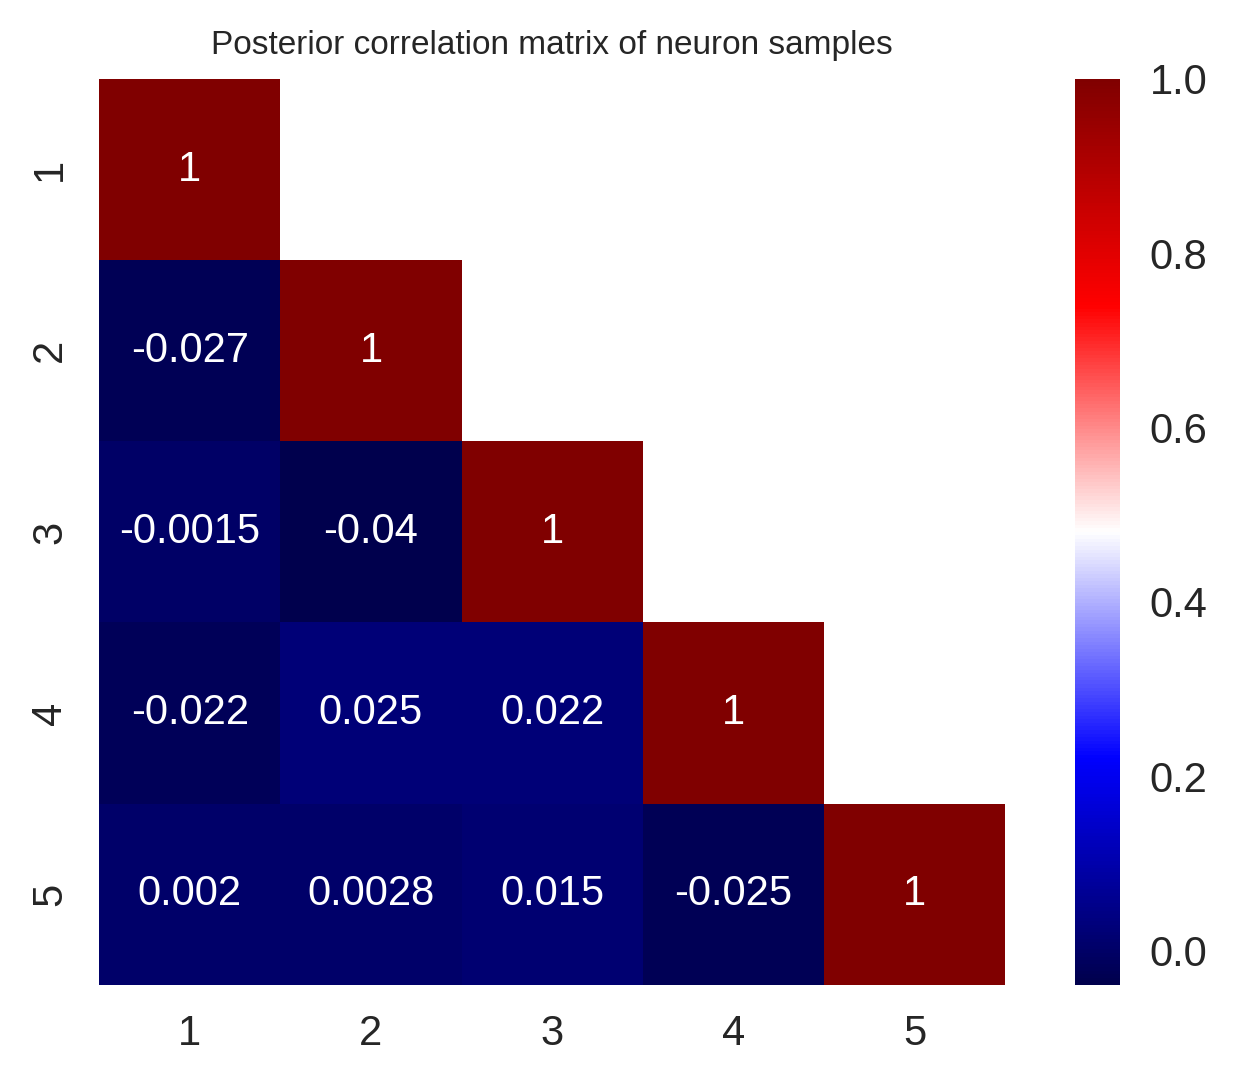

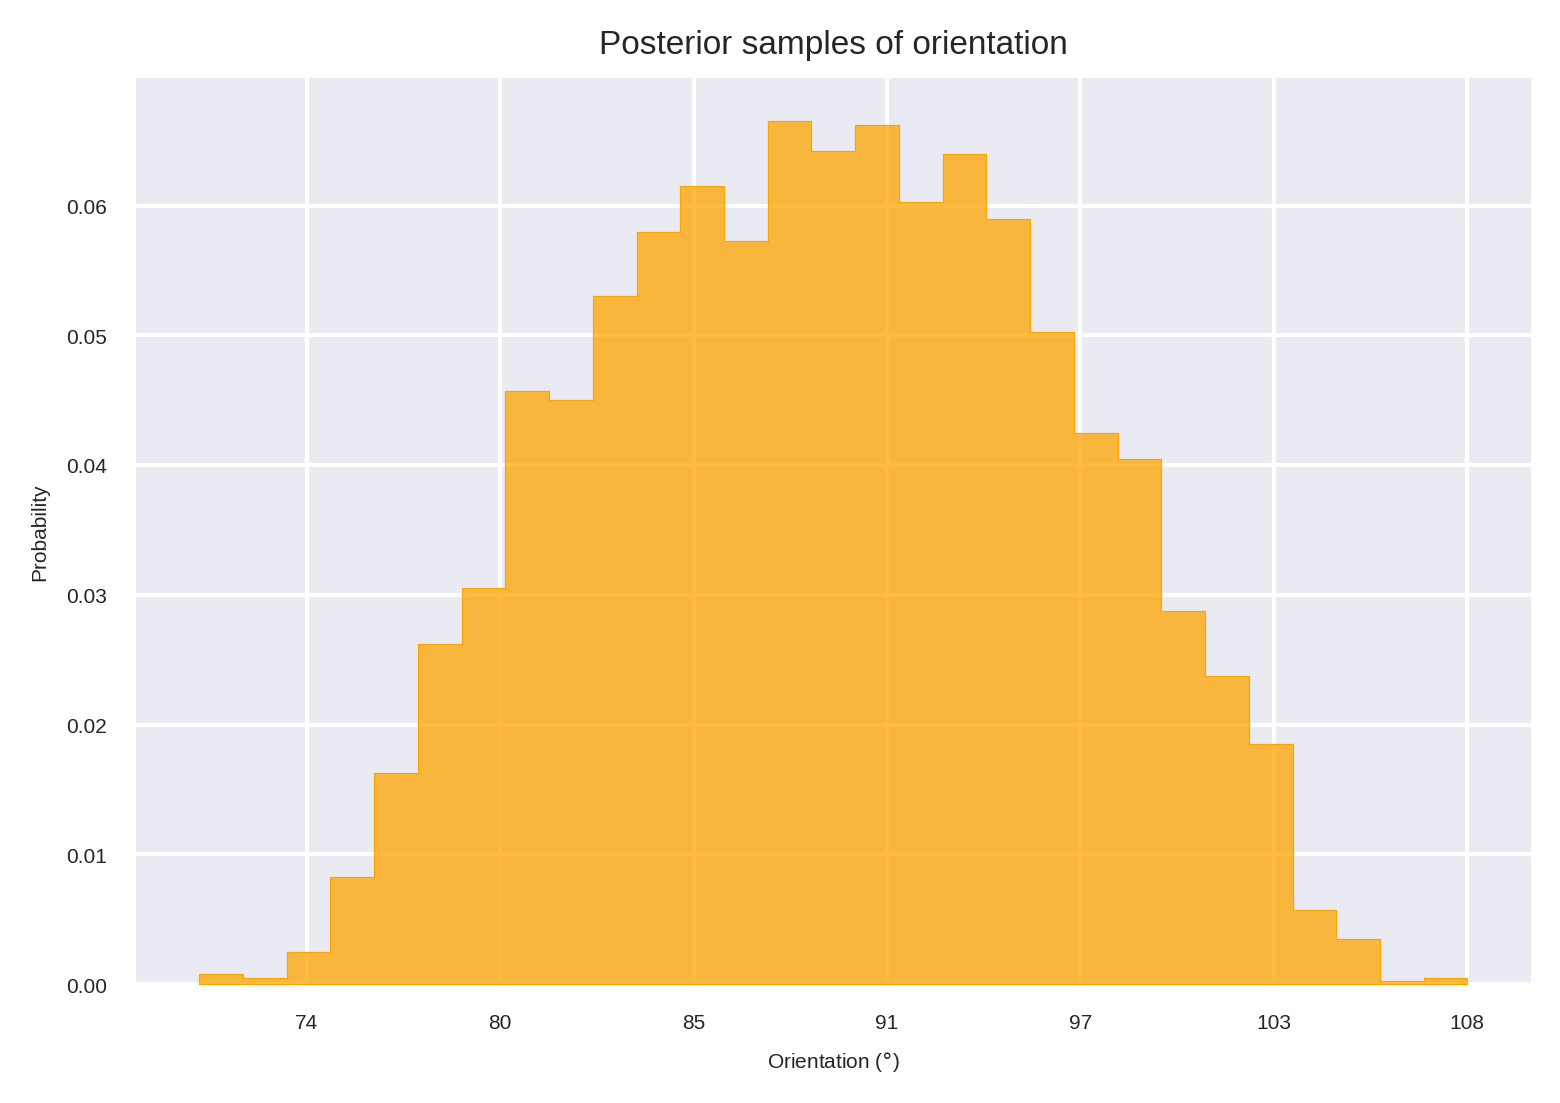

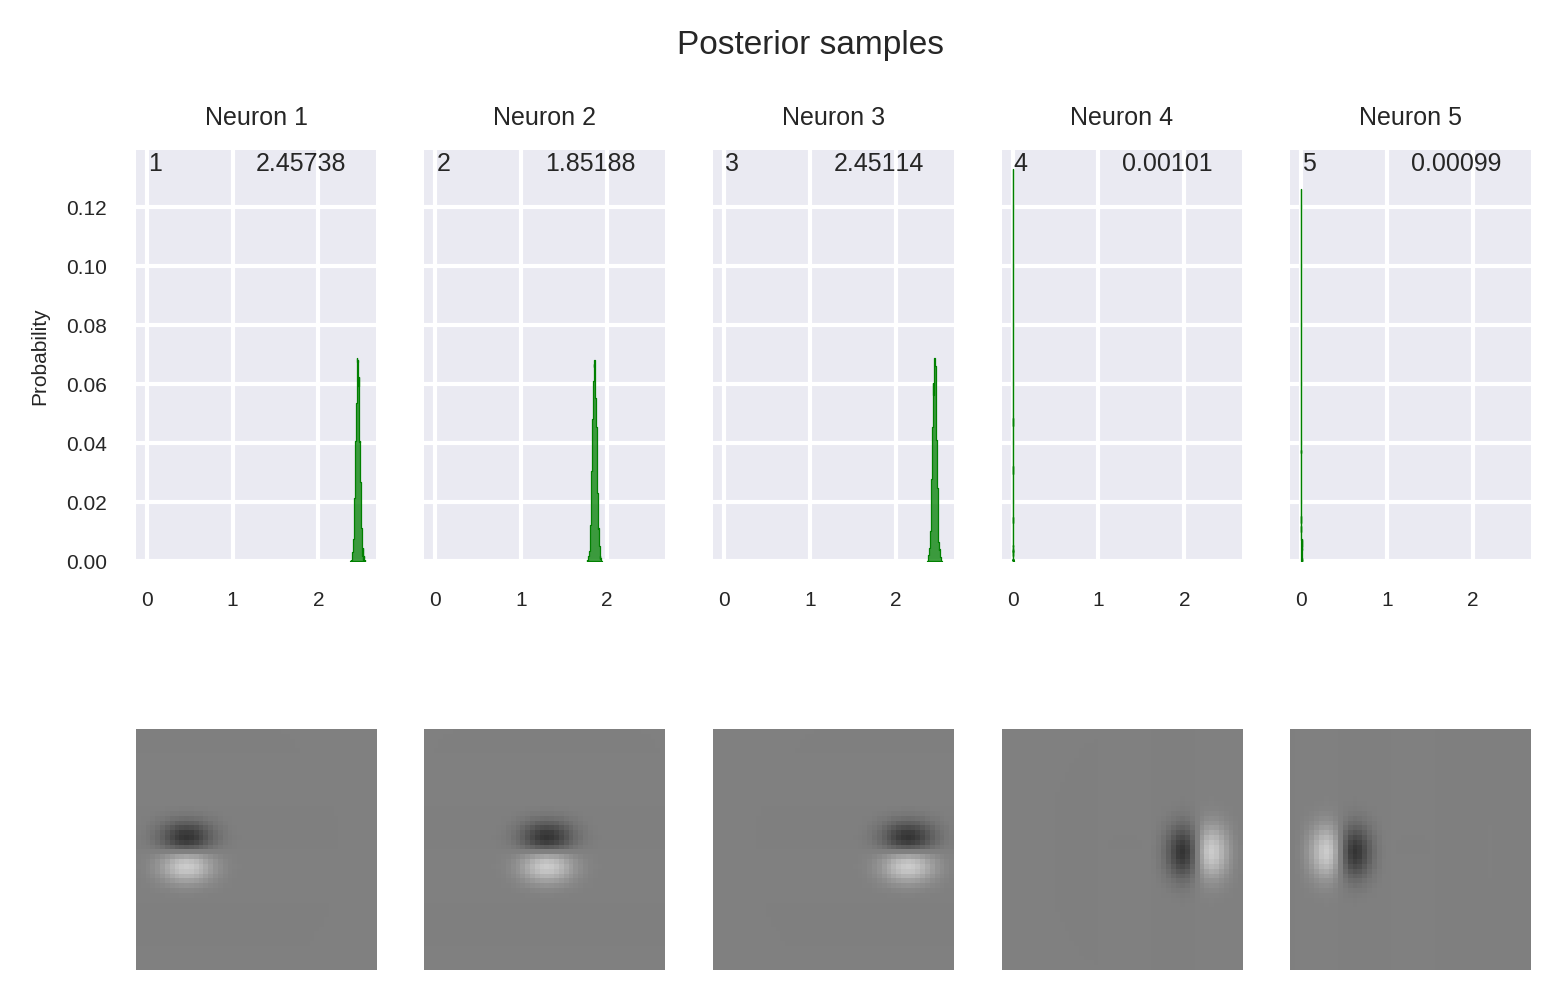

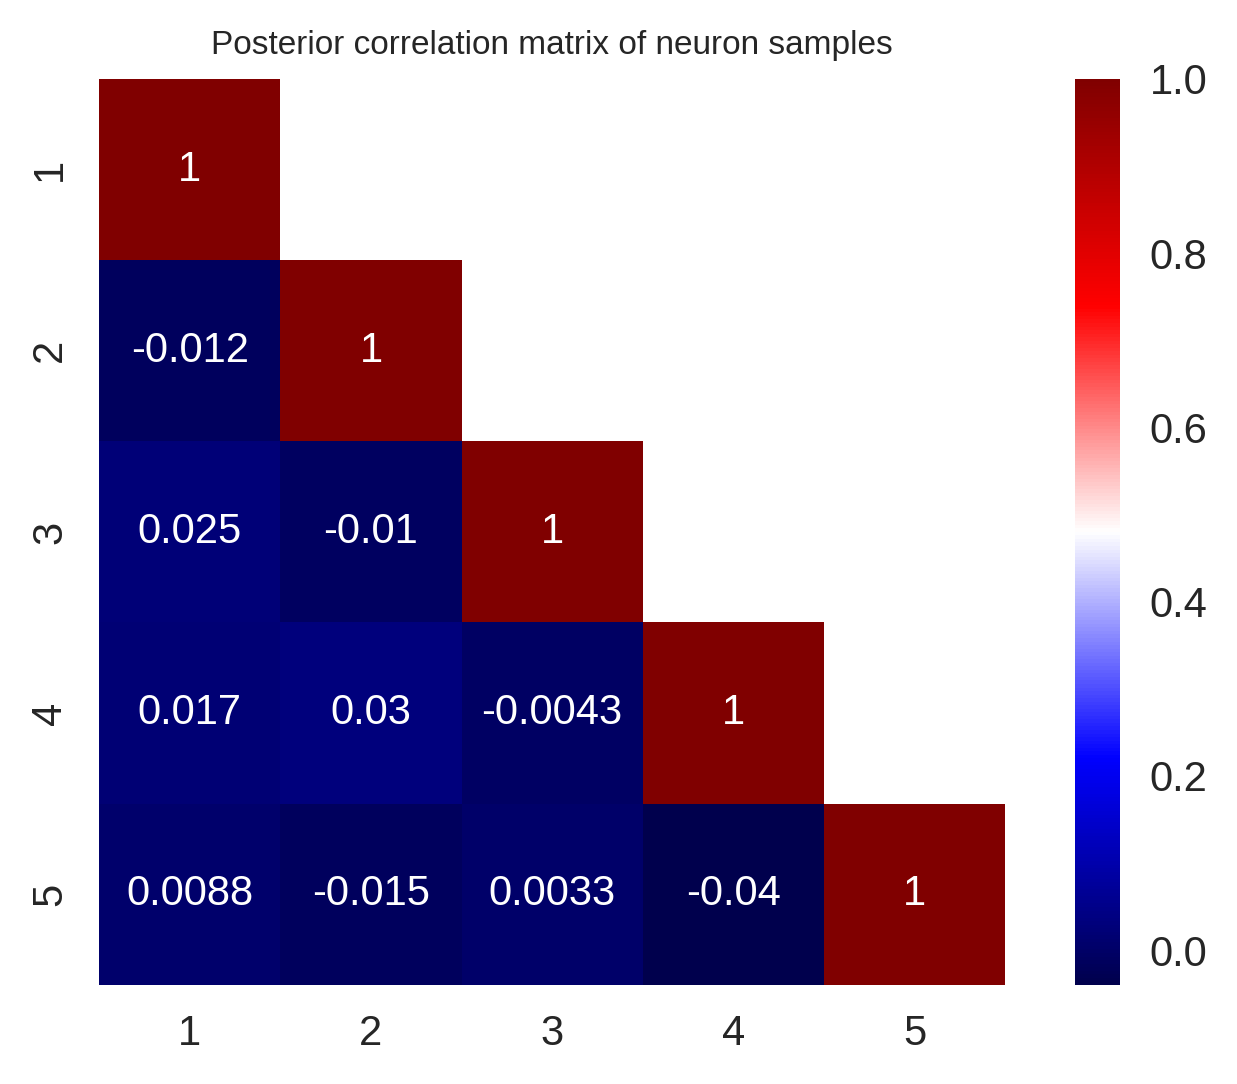

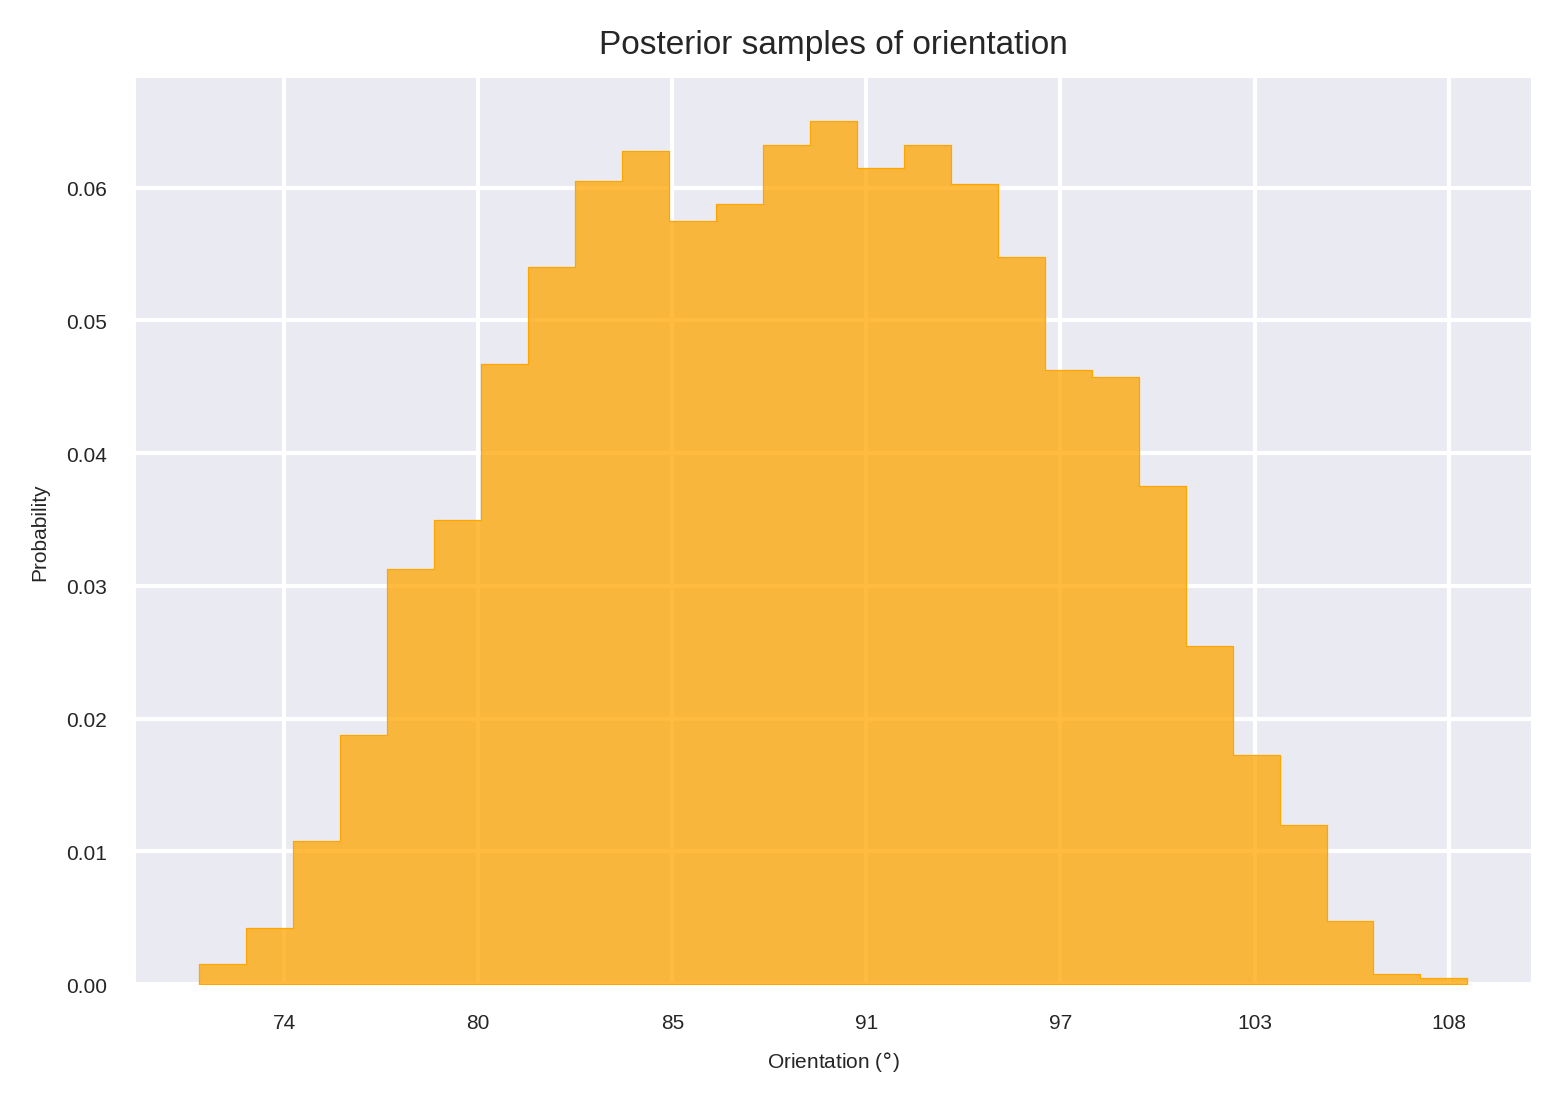

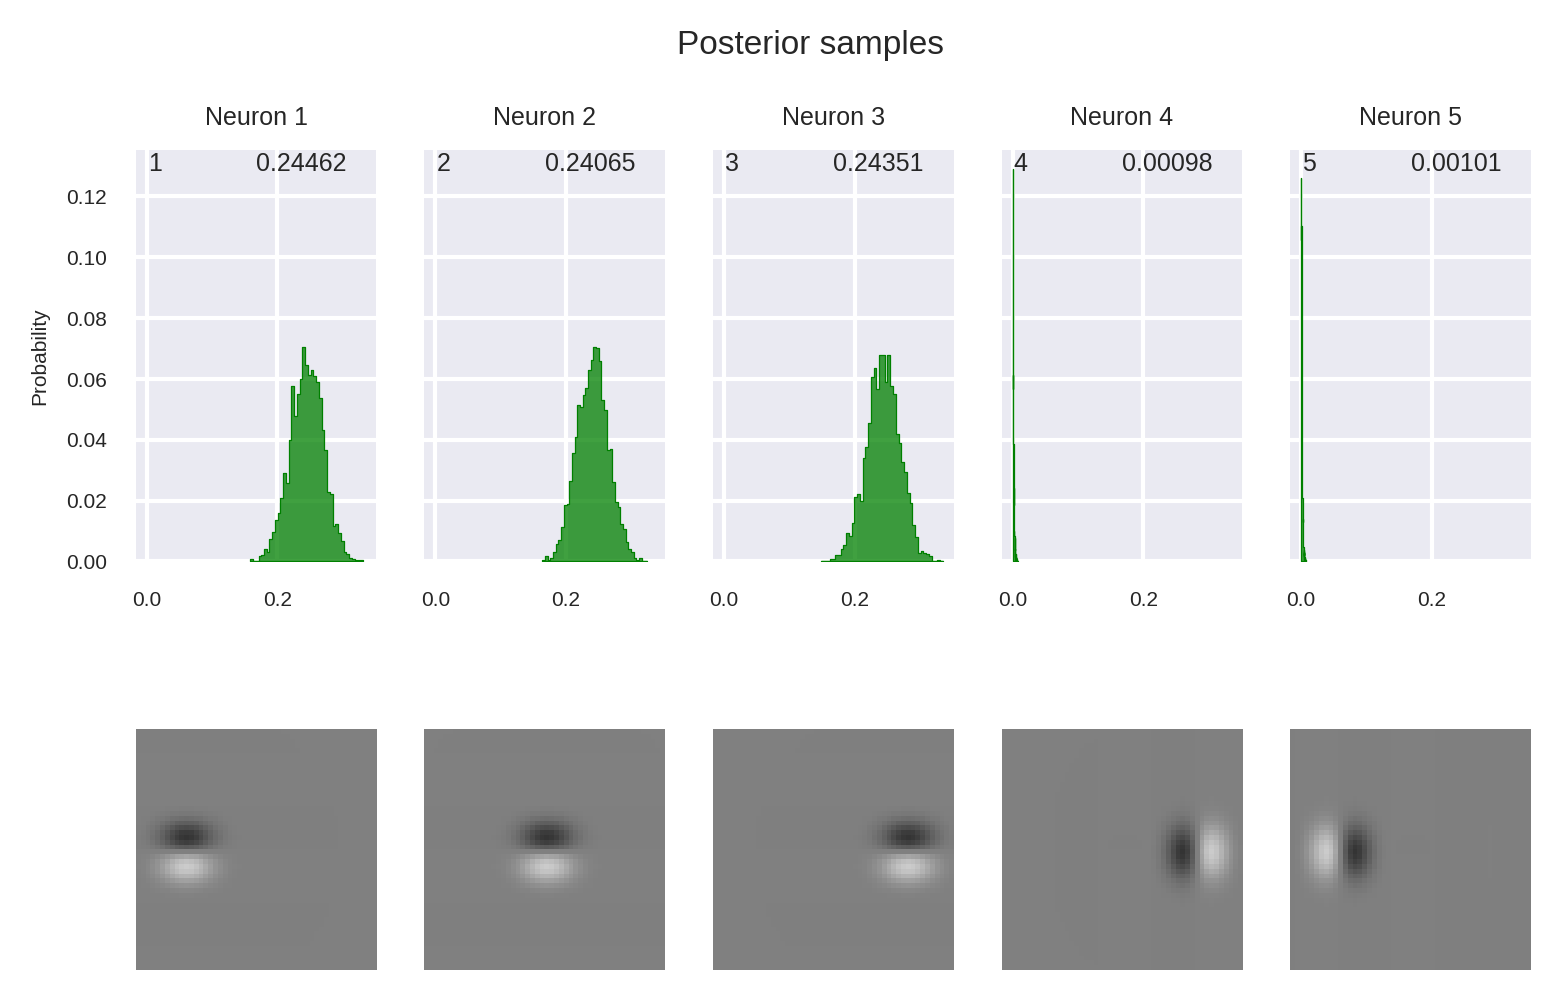

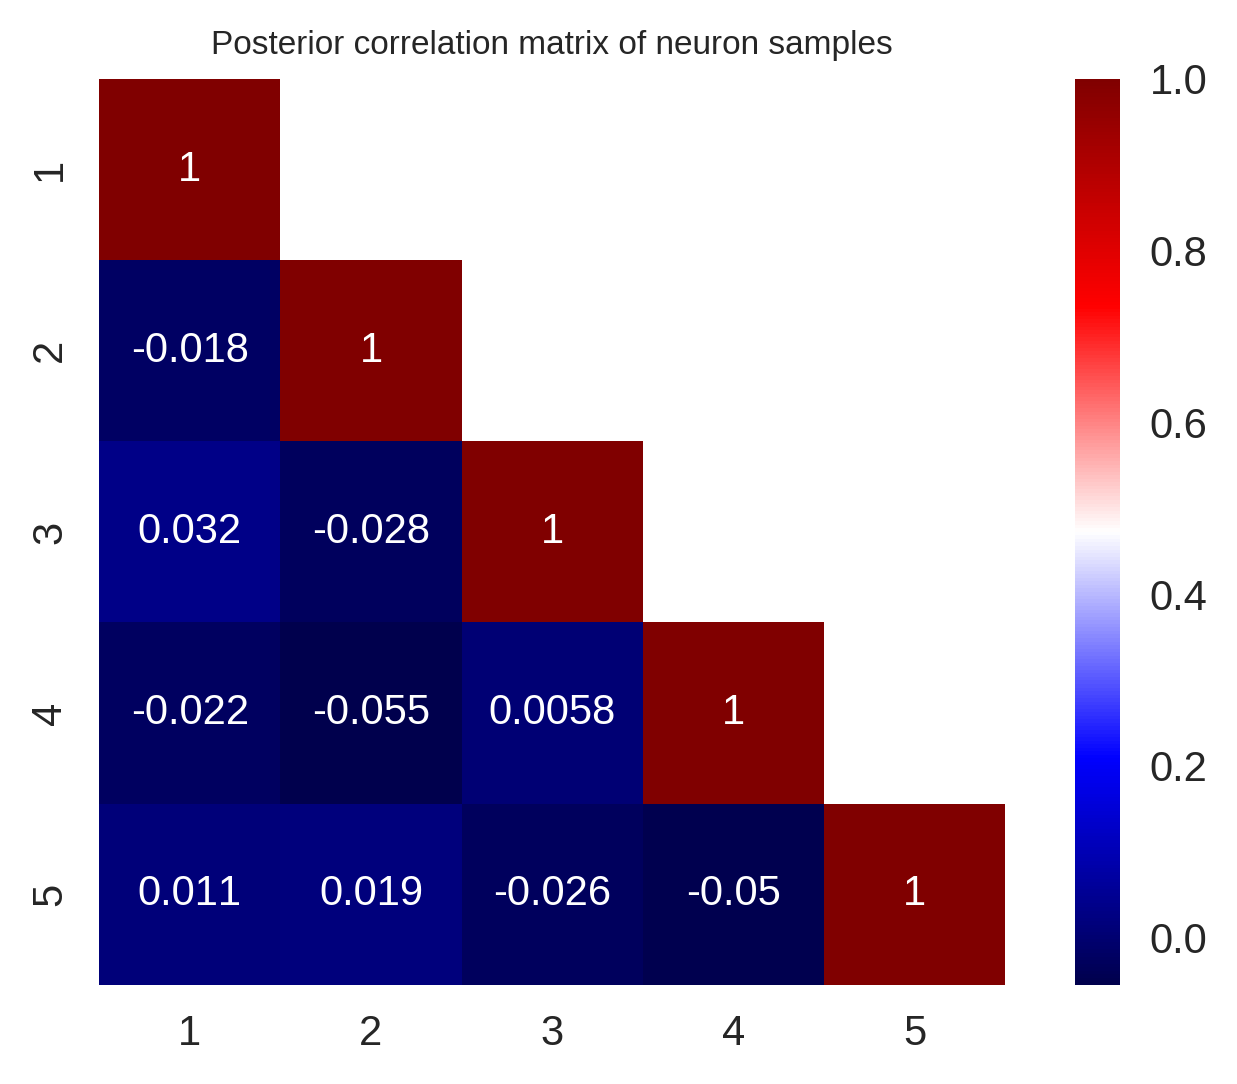

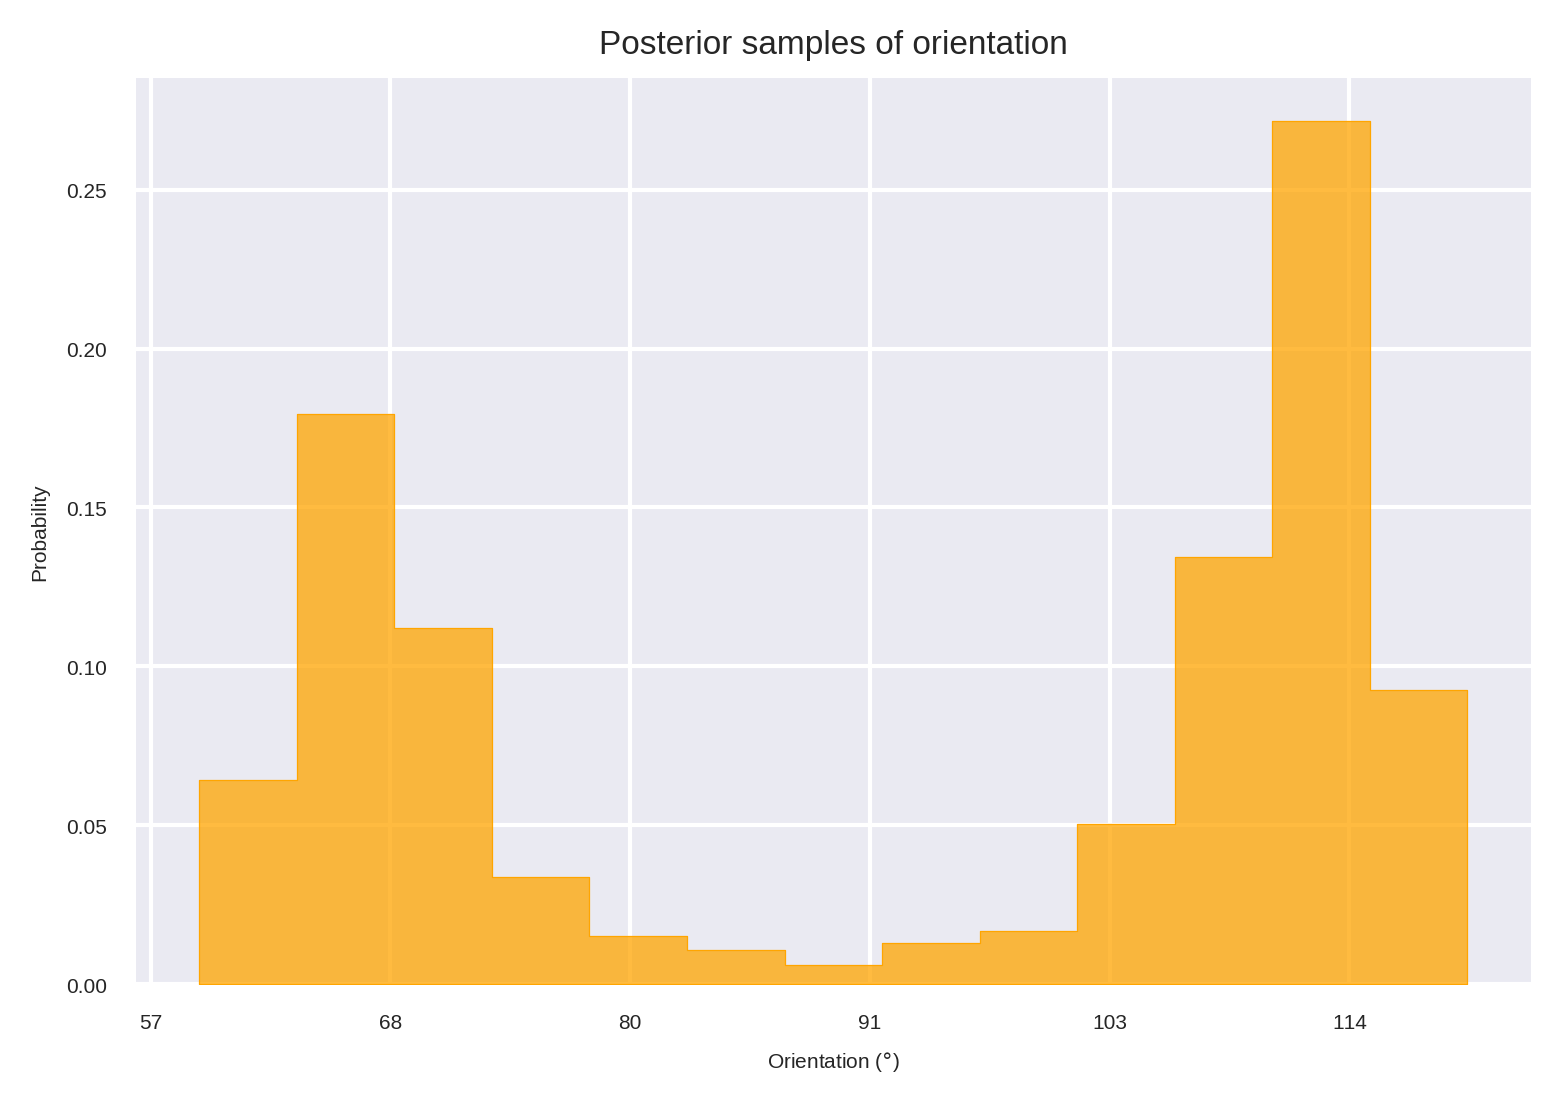

In [8]:
for trace, stimulus in zip(
    [blank_trace, center_cut_trace, incongruent_trace, incongruent_no_center_trace, congruent_trace, congruent_no_center_trace, contrast_matched_trace],
    [blank_stimulus, center_only_stimulus, incongruent_surround_stimulus, incongruent_no_center_stimulus, congruent_surround_stimulus, congruent_no_center_stimulus, contrast_matched_congruent_stimulus],
):
    analyze_posterior(trace, gabor_filters, config)

In [13]:
def analyze_traces(blank_trace, center_cut_trace, incongruent_trace, incongruent_no_center_trace, congruent_trace, congruent_no_center_trace, contrast_matched_trace):
    center_neuron_id = 1
    fig, ax = plt.subplots(dpi=300)
    sns.histplot(
        blank_trace["neurons"][:, center_neuron_id].ravel(),
        label="Baseline",
        color="black",
        stat="probability",
    )
    sns.histplot(
        center_cut_trace["neurons"][:, center_neuron_id].ravel(),
        label="MEI",
        color="blue",
        stat="probability",
    )
    sns.histplot(
        congruent_trace["neurons"][:, center_neuron_id].ravel(),
        label="Congruent",
        color="green",
        stat="probability",
    )
    sns.histplot(
        congruent_no_center_trace["neurons"][:, center_neuron_id].ravel(),
        label="Congruent no center",
        color="lightgreen",
        stat="probability",
        element="step",
    )
    sns.histplot(
        contrast_matched_trace["neurons"][:, center_neuron_id].ravel(),
        label="Contrast matched",
        color="pink",
        stat="probability",
    ) 
    sns.histplot(
        incongruent_trace["neurons"][:, center_neuron_id].ravel(),
        label="Incongruent",
        color="red",
        stat="probability",
    )
    sns.histplot(
        incongruent_no_center_trace["neurons"][:, center_neuron_id].ravel(),
        label="Incongruent no center",
        color="tomato",
        stat="probability",
        element="step",
    )
    ax.set_xlabel("Mean response")
    ax.set_ylabel("Probability")
    ax.legend(prop={"size": 8}, title="Stimulus", title_fontsize=10, loc="upper center")
    ax.set_title("Posterior samples of center neuron", fontsize=8)

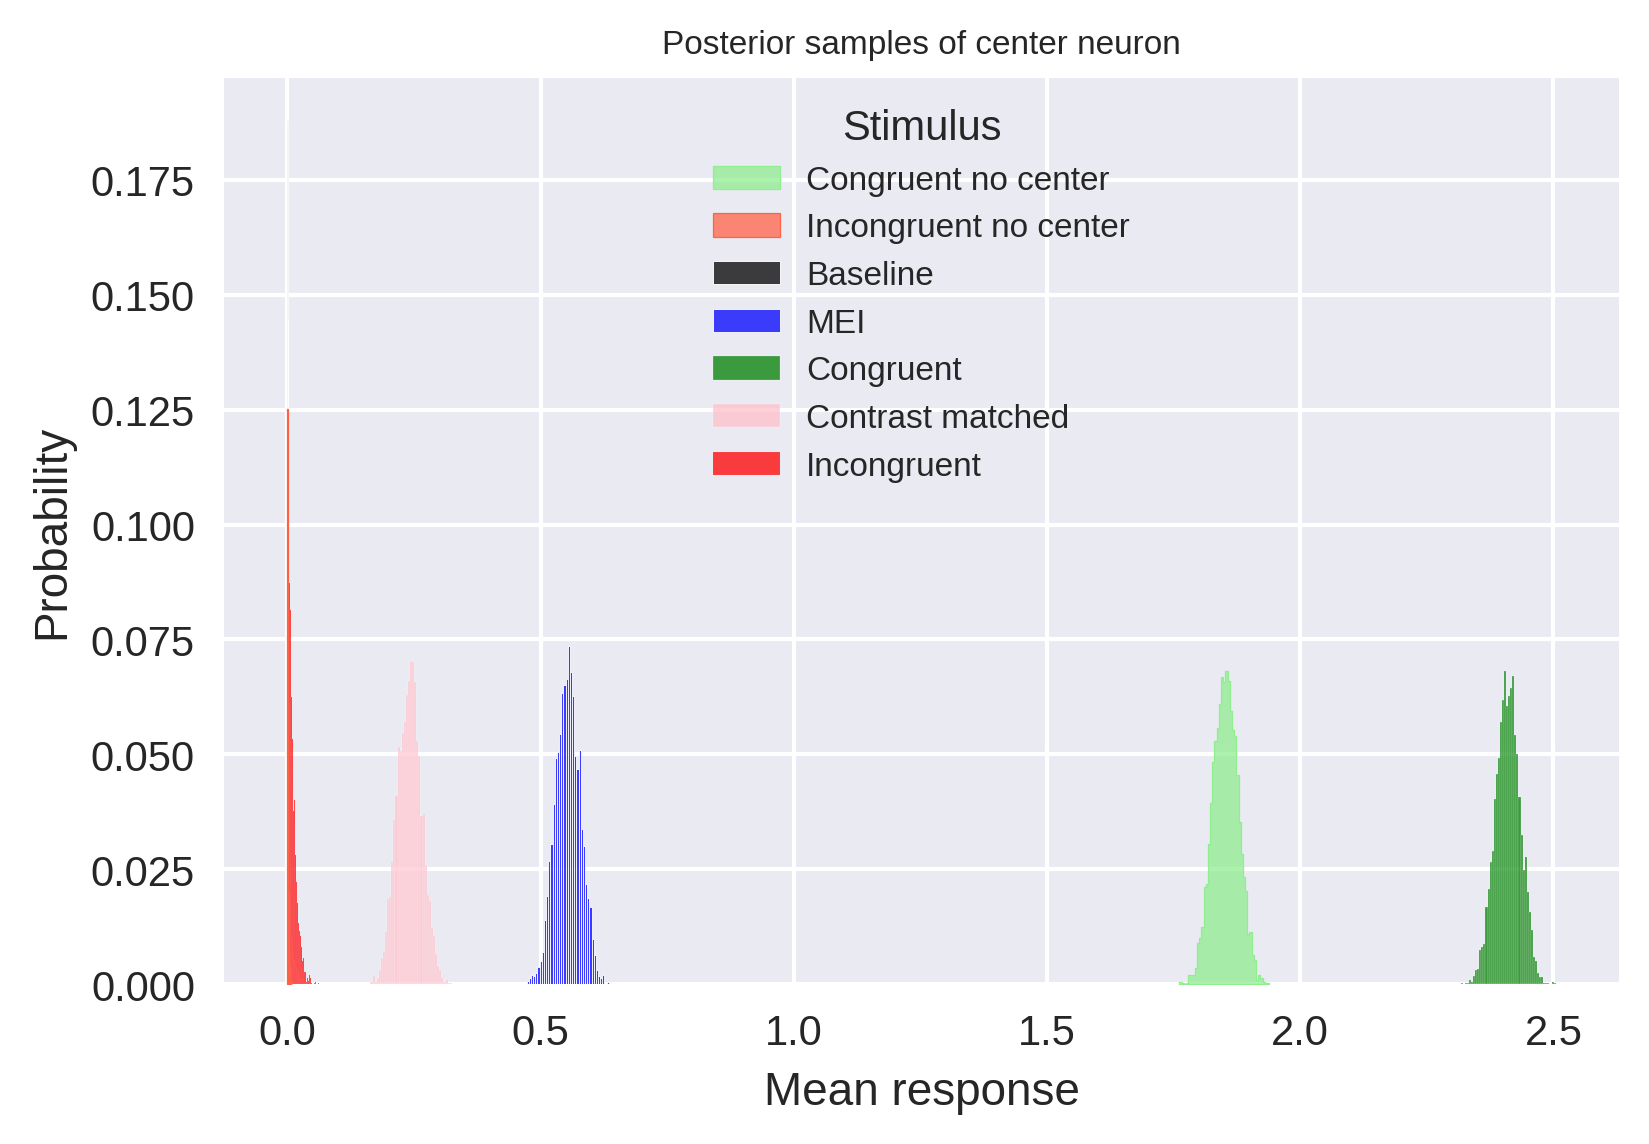

In [14]:
analyze_traces(blank_trace, center_cut_trace, incongruent_trace, incongruent_no_center_trace, congruent_trace, congruent_no_center_trace, contrast_matched_trace)


In [ ]:
fig, ax = plt.subplots(dpi=100)
center_neuron_id = 1
sns.scatterplot(x=center_cut_trace["neurons"][:, center_neuron_id].ravel(), y=congruent_trace["neurons"][:, center_neuron_id].ravel(), ax=ax)
# draw a diagonal line
ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--", c=".3")
ax.set_xlabel("MEI")
ax.set_ylabel("Congruent")
# equalize the x and y scale and ticks
ax.set_aspect("equal")
ax.set_xlim(1, 1.4)
ax.set_ylim(1, 1.4)
# make square plot
ax.set_aspect("equal")
